#FX CARRY AGENTIC TRADING SYSTEM

---

##0.REFERENCE

https://chatgpt.com/share/69f5f973-c940-83e8-a567-0710f2ebf0c6

##1.CONTEXT

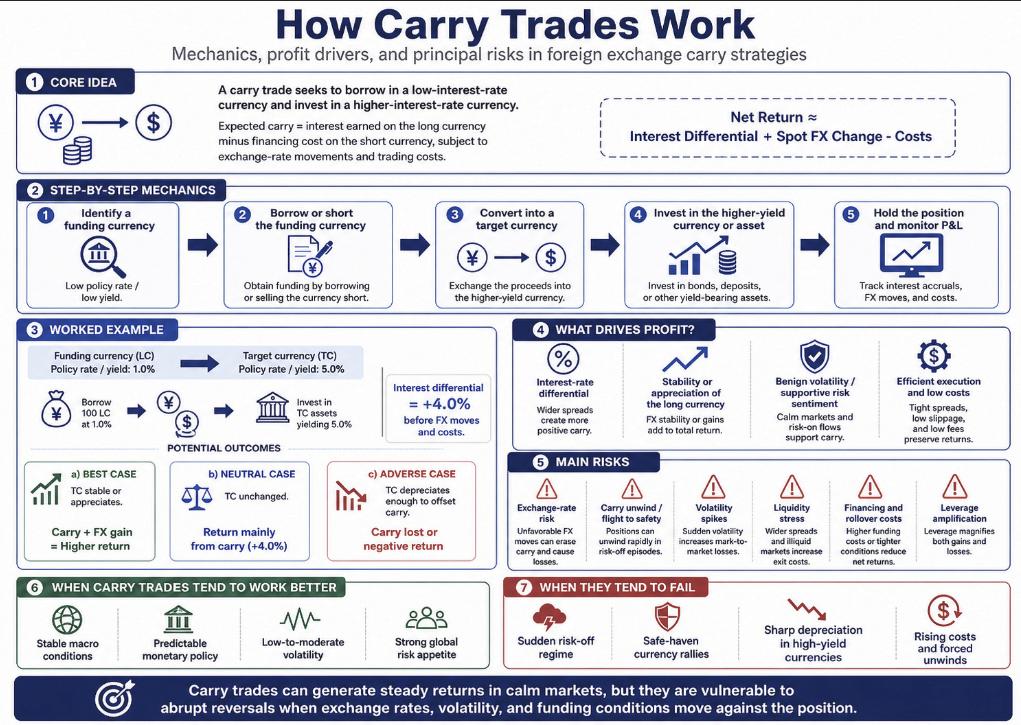

**Introduction**

This notebook introduces a governance-first, agentic trading system for foreign exchange carry strategies. The purpose is not simply to build a mechanical trading model that buys high-yield currencies and shorts low-yield currencies. That would be too easy, too fragile, and frankly too close to the kind of spreadsheet heroism that looks brilliant until the market changes regime and everyone suddenly discovers the spiritual meaning of drawdown. The purpose of this notebook is more serious: to show how a carry trading idea can be transformed into an auditable, explainable, risk-aware, committee-reviewable workflow.

The strategy studied here is an FX carry trade across five currencies: USD, JPY, CHF, AUD, and MXN. In simple terms, a carry trade tries to borrow or short a low-yielding currency and invest in a higher-yielding currency. If the high-yielding currency remains stable or appreciates, the strategy may earn the interest-rate differential and possibly benefit from favorable spot movement. But if the high-yielding currency depreciates, if volatility rises, if funding currencies rally, or if liquidity disappears, the trade can lose much more than the carry it expected to collect. This is why the notebook does not treat carry as free income. It treats carry as a risk premium that must be evaluated, constrained, stressed, and explained.

The notebook uses synthetic data. This is deliberate. Synthetic data allow us to create a controlled laboratory where the hidden market regime is known to the data generator but not directly handed to the trading agents. This distinction matters. In real markets, a trader never receives a message from the universe saying, “Congratulations, you are currently in a risk-on carry regime.” The trader observes spot prices, interest rates, volatility, liquidity, and macro behavior, and then tries to infer the state of the world. The notebook preserves that logic. The synthetic data generator creates the world, but the downstream trading agents must work from observable evidence.

The synthetic market contains three regimes. The first is a Risk-On Carry regime, where high-yield currencies are generally more attractive, volatility is moderate, and carry strategies may perform well. The second is a Neutral or Compression regime, where interest-rate spreads may narrow, signals may become less reliable, and the system should reduce its level of conviction. The third is a Risk-Off Carry-Unwind regime, where high-yield currencies may fall, funding currencies may rally, liquidity may worsen, and the strategy may experience the kind of abrupt reversal that makes carry trading dangerous. The notebook is therefore not designed around one static environment. It is designed around changing market conditions.

The workflow is built using LangGraph. This matters because the system is not merely a chain of notebook cells. It is an agentic workflow in which each agent has a defined responsibility. One agent generates the synthetic data. Another agent checks the data quality and lineage. Another agent infers the market regime using a hidden Markov model. A set of currency agents evaluates the individual currencies. Another agent constructs candidate carry pairs. A coordinator builds a preliminary basket. A risk allocation agent applies exposure limits and regime throttles. A stress agent attacks the portfolio under adverse scenarios. An execution and financing agent subtracts costs. A model evaluation agent measures performance. An audit bundle agent preserves the evidence. A committee report agent explains the results in plain language.

This division of labor is the core governance idea. A serious trading system should not allow a single signal to become a trade, a trade to become a portfolio, a portfolio to become a performance chart, and a performance chart to become a conclusion without review. Each transformation must be visible. The notebook is designed so that the user can see how data become features, how features become inferred regimes, how regimes influence currency analysis, how currency analysis becomes pair selection, how pair selection becomes allocation, how allocation is constrained, how the constrained book behaves under stress, how execution costs affect returns, and how all outputs are saved for review.

The currency agents are especially important. Each currency receives its own agent because currencies do not play identical roles. MXN may be a high-yield currency with attractive carry but meaningful volatility and liquidity risk. AUD may be a risk-sensitive currency that performs well when global appetite is strong but weakens under stress. JPY and CHF may be low-yield funding currencies, but they can also behave like safe-haven currencies when carry trades unwind. USD may be a reserve currency, a base currency, a defensive currency, or a funding currency depending on the environment. The notebook therefore avoids treating currencies as anonymous yield numbers. It gives each currency an interpreted role.

The currency agents use deterministic evidence and, when available, Claude as the language model engine. The model used is Claude Haiku 4.5, accessed through the Anthropic API key stored in Colab secrets. The LLM does not invent market data. It does not approve trades. It does not replace the risk manager. It receives structured evidence and produces a bounded memo: recommendation, confidence, role classification, risk flags, regime interpretation, and committee summary. If the LLM call fails, the notebook uses deterministic fallback and records that fallback. This is intentional. In a governed AI workflow, it is not enough to use a model. The system must know whether the model was actually called, whether its output was parseable, and whether fallback logic was used.

The notebook also includes a regime detection agent based on a hidden Markov model. This agent receives observable features such as volatility, carry dispersion, funding-currency strength, high-yield momentum, liquidity proxies, and drawdown indicators. It then classifies the current synthetic environment into one of the three regimes. The regime output is not treated as truth. It is treated as a model output with uncertainty. The downstream agents use it, but the system also records confidence and warnings. This is important because a regime label can sound authoritative even when it is only an inference.

The portfolio construction process is intentionally layered. Currency-level recommendations do not directly become allocations. First, the pair construction agent identifies possible long-short carry pairs. Then the basket coordinator combines selected pairs into a preliminary portfolio. Then the capital and risk allocation agent applies limits. This separation is important because a currency can be attractive individually but dangerous in a pair, and a pair can be attractive individually but dangerous inside a basket. For example, several pairs may all be long risk-sensitive currencies and short safe-haven funding currencies. That may look diversified by number of trades, but economically it may be one large bet on global risk appetite.

The risk allocation agent is the boundary between research opinion and capital expression. It applies gross exposure limits, currency exposure caps, volatility scaling, confidence adjustments, and regime throttles. In a Risk-On Carry regime, the system may allow more exposure. In a Neutral or Compression regime, the system should reduce exposure but not necessarily eliminate it. In a Risk-Off Carry-Unwind regime, the system should materially reduce classic carry exposure. This is where governance becomes operational. Risk controls are not decorative text in a report. They change the portfolio.

The stress risk agent then asks the uncomfortable questions. What happens if JPY rallies sharply? What happens if CHF behaves as a safe haven? What happens if MXN crashes? What happens if liquidity evaporates? What happens if dollar funding tightens? Carry strategies often look best before they are tested against exactly these scenarios. The stress agent does not exist to make the model feel good. It exists to challenge the portfolio before the committee does.

The execution and financing agent adds another layer of realism. A strategy that looks good before costs may not survive spreads, slippage, financing haircuts, turnover, and liquidity penalties. The notebook therefore separates gross return from net return. It shows how much comes from spot movement, how much comes from carry, and how much is consumed by costs. This distinction is essential because carry is often described as if it were a clean interest-rate spread. In practice, implementation matters.

Finally, the notebook produces an audit bundle and a committee report. The audit bundle preserves the run manifest, configuration, data, regime outputs, currency memos, pair tables, allocations, stress results, execution results, evaluation metrics, logs, figures, and final report. The committee report translates the structured evidence into readable prose. The final output is not a trade instruction. It is a decision package. It is designed for review, challenge, and further research.

This notebook should therefore be understood as a teaching system for governed agentic trading. It demonstrates how a modern AI-assisted trading workflow can combine synthetic data, statistical inference, deterministic rules, LLM-backed interpretation, portfolio construction, risk management, stress testing, execution adjustment, performance evaluation, and auditability. It does not claim live profitability. It does not provide investment advice. It shows how to build a serious research workflow in which evidence comes before recommendation, risk comes before deployment, audit comes before confidence, and human review remains the final authority.

##2.CODE AND IMPLEMENTATION

###2.1.LIBRARIES AND ENVIRONMENT

**Cell 1 Explanation**

Cell 1 prepares the full working environment for the notebook. It installs the required Python packages, imports the main libraries, creates the folder structure, defines the central configuration, loads the Claude API key from Colab secrets, and sets up several governance utilities that will be used throughout the system.

The most important idea in this cell is that the notebook begins with structure rather than improvisation. Before any synthetic data are created or any trading signals are generated, the notebook defines a run identifier, output folders, configuration settings, model name, risk limits, cost assumptions, and verification warning. This is a governance-first habit. A serious workflow should know where its artifacts will be saved, what assumptions it is using, and how the run can be identified later.

The folder structure is also important. The notebook creates separate folders for data, artifacts, reports, figures, logs, and Mermaid diagrams. This prevents the run from becoming a messy collection of temporary notebook outputs. Every later agent can save its results in a predictable location. This makes the final audit bundle possible.

Cell 1 also loads the Anthropic Claude client. It checks for the API key in Colab secrets. Because there was a spelling issue in the user's instruction, the code checks both the standard key name and the misspelled version. If the key is available, Claude is enabled. If not, the notebook does not collapse. It simply records that LLM functionality is unavailable and later agents can use deterministic fallback. This is important because a governed system should be resilient to missing API access.

Another important part of Cell 1 is the robust JSON parsing logic. LLMs sometimes return extra text, code fences, or imperfect JSON. The notebook anticipates that problem and includes functions to strip code fences, extract the largest JSON object, and attempt limited repair. This allows LLM outputs to be used in a structured workflow without assuming that the model will always behave perfectly.

Cell 1 also defines the Claude call wrapper. This wrapper records whether the LLM was enabled, whether the call succeeded, whether parsing succeeded, whether fallback was used, and what model was called. This is one of the most important governance features in the notebook. It is not enough to call an LLM; the system must know whether the call actually worked.

Finally, Cell 1 creates the run manifest. The manifest records the run ID, timestamp, configuration, model name, LLM status, and verification notice. This manifest becomes part of the audit bundle. In plain terms, Cell 1 is the institutional foundation of the notebook. It says: before we trade, we document the rules of the game.

In [1]:
# ============================================================
# CELL 1 — ENVIRONMENT, CONFIGURATION, CLAUDE CLIENT, HELPERS
# Governance-First Agentic FX Carry Trading System
# ============================================================

!pip -q install langgraph langchain-core anthropic hmmlearn pandas numpy matplotlib scikit-learn networkx

import os
import re
import json
import math
import time
import hashlib
import zipfile
import textwrap
import warnings
import datetime
from pathlib import Path
from typing import Dict, List, Any, Optional, Tuple, TypedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

from IPython.display import display, Markdown, Image, HTML
from google.colab import userdata

from langgraph.graph import StateGraph, END

try:
    import anthropic
except Exception:
    anthropic = None

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# UTC timestamp helper — uses timezone-aware UTC
# ------------------------------------------------------------

def utc_now_iso() -> str:
    return datetime.datetime.now(datetime.timezone.utc).isoformat()

# ------------------------------------------------------------
# Main configuration
# ------------------------------------------------------------

RUN_ID = "fx_carry_agentic_" + datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%d_%H%M%S")

BASE_DIR = Path("/content/fx_carry_agentic_system")
DATA_DIR = BASE_DIR / "data"
ARTIFACT_DIR = BASE_DIR / "artifacts"
REPORT_DIR = BASE_DIR / "reports"
FIGURE_DIR = BASE_DIR / "figures"
LOG_DIR = BASE_DIR / "logs"
MERMAID_DIR = BASE_DIR / "mermaid"

for d in [BASE_DIR, DATA_DIR, ARTIFACT_DIR, REPORT_DIR, FIGURE_DIR, LOG_DIR, MERMAID_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "run_id": RUN_ID,
    "created_at_utc": utc_now_iso(),
    "random_seed": 42,
    "n_days": 900,
    "currencies": ["USD", "JPY", "CHF", "AUD", "MXN"],
    "base_currency": "USD",
    "regimes": {
        0: "Risk-On Carry",
        1: "Neutral / Compression",
        2: "Risk-Off Carry-Unwind"
    },
    "initial_capital": 1_000_000.0,
    "annualization_factor": 252,
    "max_gross_exposure": 1.50,
    "max_abs_currency_weight": 0.60,
    "max_abs_pair_weight": 0.75,
    "target_volatility_annual": 0.12,
    "risk_on_throttle": 1.00,
    "neutral_throttle": 0.50,
    "risk_off_throttle": 0.15,
    "base_spread_bps": 2.0,
    "base_slippage_bps": 1.5,
    "base_financing_haircut_bps": 0.5,
    "stress_loss_red_threshold": -0.08,
    "stress_loss_amber_threshold": -0.04,
    "anthropic_model": "claude-haiku-4-5-20251001",
    "llm_enabled": True,
    "verification_status": "Not verified — synthetic educational system; human review required."
}

np.random.seed(CONFIG["random_seed"])

def stable_hash(obj: Any) -> str:
    raw = json.dumps(obj, sort_keys=True, default=str).encode("utf-8")
    return hashlib.sha256(raw).hexdigest()

CONFIG["config_hash"] = stable_hash(CONFIG)

# ------------------------------------------------------------
# Colab secrets: robustly check both spellings
# User wrote ANTHTROPIC_API_KEY; prior notebook used ANTHROPIC_API_KEY.
# This code accepts either.
# ------------------------------------------------------------

def get_anthropic_key() -> Optional[str]:
    possible_names = ["ANTHROPIC_API_KEY", "ANTHTROPIC_API_KEY"]
    for name in possible_names:
        try:
            val = userdata.get(name)
            if val:
                print(f"Claude API key loaded from Colab secret: {name}")
                return val
        except Exception:
            pass
    env_val = os.environ.get("ANTHROPIC_API_KEY") or os.environ.get("ANTHTROPIC_API_KEY")
    if env_val:
        print("Claude API key loaded from environment variable.")
        return env_val
    print("WARNING: Claude API key not found. LLM-backed agents will use deterministic fallback.")
    return None

ANTHROPIC_API_KEY = get_anthropic_key()

if anthropic is not None and ANTHROPIC_API_KEY:
    CLAUDE_CLIENT = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
else:
    CLAUDE_CLIENT = None
    CONFIG["llm_enabled"] = False

# ------------------------------------------------------------
# Robust JSON extraction for LLM outputs
# ------------------------------------------------------------

def strip_code_fences(text: str) -> str:
    text = text.strip()
    text = re.sub(r"^```(?:json)?\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"\s*```$", "", text)
    return text.strip()

def extract_largest_json_object(text: str) -> Optional[str]:
    text = strip_code_fences(text)
    starts = [i for i, ch in enumerate(text) if ch == "{"]
    best = None
    for start in starts:
        depth = 0
        for i in range(start, len(text)):
            if text[i] == "{":
                depth += 1
            elif text[i] == "}":
                depth -= 1
                if depth == 0:
                    candidate = text[start:i+1]
                    if best is None or len(candidate) > len(best):
                        best = candidate
                    break
    return best

def robust_json_parse(text: str) -> Tuple[Optional[dict], str]:
    if not text:
        return None, "empty_text"
    candidate = extract_largest_json_object(text)
    if candidate is None:
        return None, "no_json_object_found"
    try:
        return json.loads(candidate), "parsed"
    except Exception as e:
        repaired = candidate.replace("\n", " ").replace("\t", " ")
        repaired = re.sub(r",\s*}", "}", repaired)
        repaired = re.sub(r",\s*]", "]", repaired)
        try:
            return json.loads(repaired), "parsed_after_repair"
        except Exception as e2:
            return None, f"parse_failed: {str(e2)[:200]}"

# ------------------------------------------------------------
# Claude call wrapper
# ------------------------------------------------------------

def call_claude_json(
    system_prompt: str,
    user_prompt: str,
    fallback: dict,
    max_tokens: int = 1200,
    temperature: float = 0.1
) -> dict:
    diagnostics = {
        "llm_enabled": CONFIG.get("llm_enabled", False),
        "model": CONFIG["anthropic_model"],
        "call_status": "not_called",
        "parse_status": "not_attempted",
        "fallback_used": False,
        "error": None,
        "raw_text_excerpt": None,
        "called_at_utc": utc_now_iso()
    }

    if not CONFIG.get("llm_enabled", False) or CLAUDE_CLIENT is None:
        diagnostics.update({
            "call_status": "skipped_no_client_or_key",
            "fallback_used": True
        })
        out = dict(fallback)
        out["_llm_diagnostics"] = diagnostics
        return out

    try:
        msg = CLAUDE_CLIENT.messages.create(
            model=CONFIG["anthropic_model"],
            max_tokens=max_tokens,
            temperature=temperature,
            system=system_prompt,
            messages=[{"role": "user", "content": user_prompt}]
        )
        raw = msg.content[0].text if msg.content else ""
        diagnostics["call_status"] = "success"
        diagnostics["raw_text_excerpt"] = raw[:500]
        parsed, parse_status = robust_json_parse(raw)
        diagnostics["parse_status"] = parse_status

        if parsed is None:
            diagnostics["fallback_used"] = True
            out = dict(fallback)
            out["_llm_diagnostics"] = diagnostics
            return out

        parsed["_llm_diagnostics"] = diagnostics
        return parsed

    except Exception as e:
        diagnostics.update({
            "call_status": "error",
            "fallback_used": True,
            "error": str(e)[:500]
        })
        out = dict(fallback)
        out["_llm_diagnostics"] = diagnostics
        return out

# ------------------------------------------------------------
# Artifact and logging helpers
# ------------------------------------------------------------

def save_json(path: Path, obj: Any) -> str:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, default=str)
    return str(path)

def save_text(path: Path, text: str) -> str:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        f.write(text)
    return str(path)

def artifact_record(agent: str, purpose: str, output_path: str, summary: str, limitations: str = "") -> dict:
    return {
        "agent": agent,
        "created_at_utc": utc_now_iso(),
        "purpose": purpose,
        "output_path": output_path,
        "summary": summary,
        "limitations": limitations,
        "verification_status": CONFIG["verification_status"],
        "artifact_hash": stable_hash({
            "agent": agent,
            "purpose": purpose,
            "output_path": output_path,
            "summary": summary,
            "limitations": limitations
        })
    }

MANIFEST = {
    "run_id": RUN_ID,
    "created_at_utc": CONFIG["created_at_utc"],
    "config": CONFIG,
    "config_hash": CONFIG["config_hash"],
    "llm_engine": "Anthropic Claude",
    "llm_model": CONFIG["anthropic_model"],
    "llm_enabled": CONFIG["llm_enabled"],
    "api_key_secret_names_checked": ["ANTHROPIC_API_KEY", "ANTHTROPIC_API_KEY"],
    "verification_status": CONFIG["verification_status"]
}

save_json(ARTIFACT_DIR / "run_manifest.json", MANIFEST)

print("Environment ready.")
print(f"Run ID: {RUN_ID}")
print(f"Base folder: {BASE_DIR}")
print(f"Claude enabled: {CONFIG['llm_enabled']}")
print(f"Model: {CONFIG['anthropic_model']}")

Claude API key loaded from Colab secret: ANTHROPIC_API_KEY
Environment ready.
Run ID: fx_carry_agentic_20260502_165315
Base folder: /content/fx_carry_agentic_system
Claude enabled: True
Model: claude-haiku-4-5-20251001


### 2.2.STATE SECHEMA, GOVERNANCE LOGS AND ANRTIFACT UTILITIES

**Cell 2 Explanation**

Cell 2 defines the shared state of the agentic system. In a LangGraph workflow, agents do not simply pass loose variables from one cell to another. They read from and write to a shared state object. This shared state is the memory of the system. It stores data, reports, memos, tables, weights, stress results, evaluation metrics, audit outputs, and logs.

The corrected version of Cell 2 is especially important because LangGraph only preserves state fields that are declared in the state schema. In the earlier version, the HMM agent created detected regime data, but that field was not declared in the state schema. As a result, LangGraph dropped it before the currency agents could use it. The corrected Cell 2 solves that problem by declaring all important fields, including HMM outputs, pair tables, preliminary weights, final weights, execution data, and committee reports.

This is a useful lesson in agentic system design. If an output matters, it must have a defined place in the state. Otherwise, it may disappear, become inaccessible, or remain hidden in notebook memory. A governance-first architecture requires explicit state design. The system should know what objects exist, where they are stored, and which agents produce or consume them.

Cell 2 also defines logging and artifact utilities. The log function records the timestamp, agent name, action, and details of each important event. This creates an execution trail. The artifact function records what file was produced, by which agent, for what purpose, and with what limitations. These records are later used by the audit bundle agent.

The cell also defines helper functions for portfolio weight normalization, exposure caps, annualized volatility, drawdown calculation, safe conversion of values to numbers, and currency metadata. These functions support later agents but keep the notebook organized. Rather than repeating small calculations everywhere, the notebook centralizes them here.

The currency metadata function is also conceptually important. It assigns each currency an economic role. USD is treated as multi-role. JPY and CHF are funding and safe-haven candidates. AUD is risk-sensitive. MXN is high-yield and liquidity-sensitive. These roles help the LLM-backed currency agents interpret the evidence later.

In simple terms, Cell 2 creates the filing cabinet and rulebook for the whole notebook. It defines what the system is allowed to remember, how events are logged, how artifacts are recorded, and how key utility calculations are performed. Without this cell, the workflow would be a pile of calculations. With it, the workflow becomes a structured agentic system.

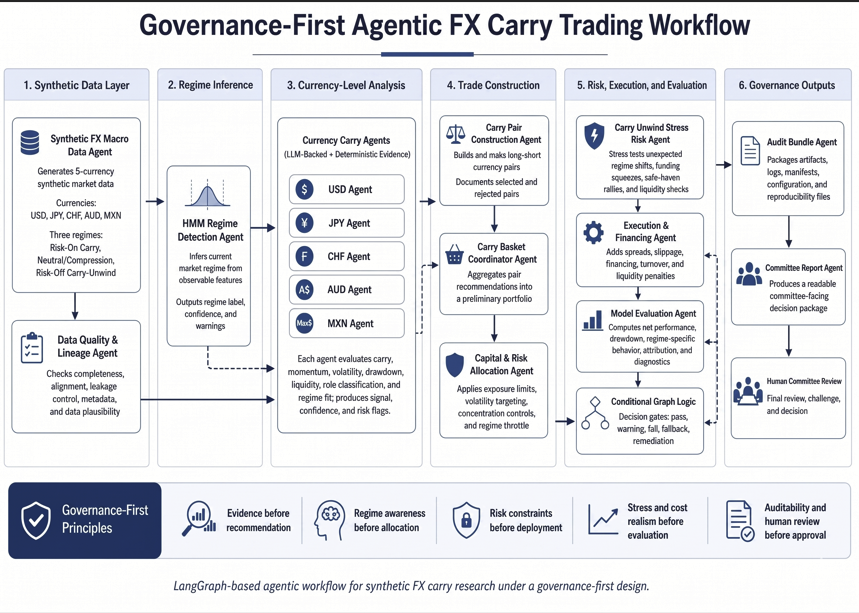

In [2]:
# ============================================================
# CELL 2 — STATE SCHEMA, GOVERNANCE LOGS, ARTIFACT UTILITIES
# CORRECTED VERSION FOR LANGGRAPH STATE RETENTION
# ============================================================

class FXCarryState(TypedDict, total=False):
    config: Dict[str, Any]
    logs: List[Dict[str, Any]]
    artifacts: List[Dict[str, Any]]

    # Core generated data
    synthetic_data: pd.DataFrame
    hidden_regimes: pd.DataFrame
    observable_features: pd.DataFrame
    currency_metadata: Dict[str, Any]

    # HMM outputs
    data_quality_report: Dict[str, Any]
    hmm_report: Dict[str, Any]
    hmm_detected_regimes: pd.DataFrame

    # Currency agent outputs
    currency_memos: Dict[str, Any]

    # Pair construction outputs
    pair_report: Dict[str, Any]
    pair_table: pd.DataFrame

    # Basket outputs
    basket_report: Dict[str, Any]
    preliminary_currency_weights: Dict[str, float]
    preliminary_pair_weights: Dict[str, float]

    # Risk allocation outputs
    risk_allocation_report: Dict[str, Any]
    final_currency_weights: Dict[str, float]

    # Stress, execution, evaluation
    stress_report: Dict[str, Any]
    execution_report: Dict[str, Any]
    execution_df: pd.DataFrame
    evaluation_report: Dict[str, Any]

    # Audit and reporting
    audit_report: Dict[str, Any]
    committee_report: Dict[str, Any]


def init_state() -> FXCarryState:
    return {
        "config": CONFIG,
        "logs": [],
        "artifacts": []
    }


def log_event(state: FXCarryState, agent: str, action: str, details: Dict[str, Any]) -> FXCarryState:
    entry = {
        "timestamp_utc": utc_now_iso(),
        "agent": agent,
        "action": action,
        "details": details
    }
    state.setdefault("logs", []).append(entry)
    return state


def add_artifact(state: FXCarryState, artifact: dict) -> FXCarryState:
    state.setdefault("artifacts", []).append(artifact)
    return state


def write_state_logs(state: FXCarryState) -> None:
    save_json(LOG_DIR / "agent_logs.json", state.get("logs", []))
    save_json(ARTIFACT_DIR / "artifact_index_live.json", state.get("artifacts", []))


def normalize_abs_weights(weights: Dict[str, float], max_gross: float) -> Dict[str, float]:
    gross = sum(abs(v) for v in weights.values())
    if gross <= max_gross or gross == 0:
        return weights
    scale = max_gross / gross
    return {k: v * scale for k, v in weights.items()}


def cap_abs_weights(weights: Dict[str, float], cap: float) -> Dict[str, float]:
    return {k: float(np.clip(v, -cap, cap)) for k, v in weights.items()}


def annualized_vol(series: pd.Series, ann: int = 252) -> float:
    s = pd.Series(series).dropna()
    if len(s) < 2:
        return 0.0
    return float(s.std() * np.sqrt(ann))


def max_drawdown(equity: pd.Series) -> float:
    e = pd.Series(equity).dropna()
    if len(e) == 0:
        return 0.0
    peak = e.cummax()
    dd = e / peak - 1.0
    return float(dd.min())


def safe_float(x, default=0.0):
    try:
        if pd.isna(x):
            return default
        return float(x)
    except Exception:
        return default


def currency_role_metadata() -> Dict[str, Any]:
    return {
        "USD": {
            "role": "multi_role_reserve_currency",
            "notes": "Can act as base, reserve, defensive, or funding currency depending on regime."
        },
        "JPY": {
            "role": "funding_safe_haven",
            "notes": "Low-yield funding candidate but can rally during carry unwinds."
        },
        "CHF": {
            "role": "funding_safe_haven",
            "notes": "Low-yield funding candidate with defensive/safe-haven behavior."
        },
        "AUD": {
            "role": "risk_sensitive_carry_currency",
            "notes": "Risk-sensitive and commodity-linked carry candidate."
        },
        "MXN": {
            "role": "high_yield_liquidity_sensitive",
            "notes": "High-carry candidate with volatility and liquidity stress vulnerability."
        }
    }


def regime_name(code: int) -> str:
    return CONFIG["regimes"].get(int(code), "Unknown")


print("Corrected state schema and governance utilities ready.")
print("Important: rerun Cell 9 after this cell.")

Corrected state schema and governance utilities ready.
Important: rerun Cell 9 after this cell.


###2.3.SYNTHETIC DATA GENERATION AGENT


**Cell 3 Explanation**

Cell 3 creates the synthetic FX market environment. This is the first operational agent in the notebook: the Synthetic FX Macro Data Agent. Its job is to generate the data that every later agent will analyze. The notebook uses five currencies: USD, JPY, CHF, AUD, and MXN. It also generates three regimes: Risk-On Carry, Neutral or Compression, and Risk-Off Carry-Unwind.

The use of synthetic data is deliberate. The purpose is not to pretend that the data are real. The purpose is to create a controlled environment where the system can demonstrate how an agentic carry workflow behaves under different market regimes. Because the data are synthetic, the notebook knows the hidden regime that generated each observation. But this hidden regime is not directly given to the trading agents. It is stored separately for later evaluation. This prevents the model from cheating.

The synthetic data include spot indices, short-term interest rates, carry differentials, spot returns, liquidity penalties, and features for regime detection. This matters because FX carry is not only about interest rates. A high-yield currency can still lose money if it depreciates. A low-yield funding currency can become dangerous if it rallies during stress. The data generator therefore creates both the return side and the interest-rate side of the carry trade.

The regime structure gives the synthetic world realistic behavior. In Risk-On Carry periods, high-yield and risk-sensitive currencies such as MXN and AUD may behave better. In Neutral or Compression periods, signals become less clear. In Risk-Off Carry-Unwind periods, high-yield currencies may suffer, funding currencies such as JPY and CHF may strengthen, volatility rises, and liquidity worsens. This gives the later agents something meaningful to analyze.

The cell also generates observable features for the HMM regime detection agent. These include measures such as global FX volatility, carry dispersion, high-yield momentum, funding-currency strength, liquidity penalty, and drawdown proxy. These are the features that the HMM agent will use to infer the regime. The true hidden regime is kept separate.

Cell 3 saves several artifacts: the synthetic data file, the hidden regime archive, the observable feature table, the currency metadata, and a generation report. These outputs are important because the rest of the notebook depends on them. If the data generator is poorly designed, every later result becomes less meaningful.

In plain language, Cell 3 builds the world in which the trading system lives. It creates currencies, regimes, interest rates, exchange-rate behavior, liquidity conditions, and observable market features. It is not merely a random number generator. It is the synthetic market laboratory for the entire governance-first experiment.

In [3]:
# ============================================================
# CELL 3 — SYNTHETIC FX MACRO DATA AGENT
# Generates 5 currencies, 3 regimes, spot, rates, carry, features
# ============================================================

def synthetic_fx_macro_data_agent(state: FXCarryState) -> FXCarryState:
    agent = "Synthetic FX Macro Data Agent"
    cfg = state["config"]
    rng = np.random.default_rng(cfg["random_seed"])

    n = cfg["n_days"]
    currencies = cfg["currencies"]
    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=n)

    # Persistent 3-regime Markov transition matrix:
    # 0 Risk-On, 1 Neutral, 2 Risk-Off
    P = np.array([
        [0.94, 0.05, 0.01],
        [0.08, 0.86, 0.06],
        [0.04, 0.16, 0.80],
    ])

    regimes = np.zeros(n, dtype=int)
    regimes[0] = 0
    for t in range(1, n):
        regimes[t] = rng.choice([0, 1, 2], p=P[regimes[t-1]])

    # Annual rate targets by regime and currency
    # Synthetic didactic assumptions
    rate_targets = {
        0: {"USD": 0.035, "JPY": 0.005, "CHF": 0.008, "AUD": 0.040, "MXN": 0.085},
        1: {"USD": 0.030, "JPY": 0.007, "CHF": 0.010, "AUD": 0.032, "MXN": 0.065},
        2: {"USD": 0.040, "JPY": 0.004, "CHF": 0.006, "AUD": 0.028, "MXN": 0.095},
    }

    # Spot return behavior by regime.
    # Positive return means currency appreciates versus synthetic USD-like numeraire.
    drift = {
        0: {"USD": 0.00000, "JPY": -0.00006, "CHF": -0.00004, "AUD": 0.00010, "MXN": 0.00016},
        1: {"USD": 0.00000, "JPY": 0.00000, "CHF": 0.00000, "AUD": 0.00000, "MXN": 0.00002},
        2: {"USD": 0.00008, "JPY": 0.00022, "CHF": 0.00018, "AUD": -0.00022, "MXN": -0.00038},
    }

    vol = {
        0: {"USD": 0.0025, "JPY": 0.0040, "CHF": 0.0038, "AUD": 0.0055, "MXN": 0.0065},
        1: {"USD": 0.0030, "JPY": 0.0048, "CHF": 0.0045, "AUD": 0.0065, "MXN": 0.0080},
        2: {"USD": 0.0060, "JPY": 0.0090, "CHF": 0.0085, "AUD": 0.0130, "MXN": 0.0200},
    }

    beta_to_risk = {
        "USD": -0.10,
        "JPY": -0.55,
        "CHF": -0.45,
        "AUD": 0.75,
        "MXN": 1.10
    }

    # Generate global risk factor: negative in risk-off
    risk_factor = np.zeros(n)
    for t in range(n):
        z = regimes[t]
        if z == 0:
            risk_factor[t] = rng.normal(0.0005, 0.004)
        elif z == 1:
            risk_factor[t] = rng.normal(0.0000, 0.006)
        else:
            risk_factor[t] = rng.normal(-0.0015, 0.014)

    # Generate spot indices
    spot = pd.DataFrame(index=dates, columns=currencies, dtype=float)
    returns = pd.DataFrame(index=dates, columns=[f"{c}_spot_return" for c in currencies], dtype=float)

    initial_spot = {"USD": 100.0, "JPY": 100.0, "CHF": 100.0, "AUD": 100.0, "MXN": 100.0}
    for c in currencies:
        spot.iloc[0, spot.columns.get_loc(c)] = initial_spot[c]
        returns.iloc[0, returns.columns.get_loc(f"{c}_spot_return")] = 0.0

    for t in range(1, n):
        z = regimes[t]
        for c in currencies:
            jump = 0.0
            if z == 2:
                if c in ["MXN", "AUD"] and rng.random() < 0.025:
                    jump = rng.normal(-0.035, 0.015)
                if c in ["JPY", "CHF"] and rng.random() < 0.018:
                    jump = rng.normal(0.020, 0.010)

            r = (
                drift[z][c]
                + beta_to_risk[c] * risk_factor[t]
                + rng.normal(0, vol[z][c])
                + jump
            )
            returns.iloc[t, returns.columns.get_loc(f"{c}_spot_return")] = r
            spot.iloc[t, spot.columns.get_loc(c)] = spot.iloc[t-1][c] * np.exp(r)

    # Generate annualized short-rate paths
    rates = pd.DataFrame(index=dates, columns=[f"{c}_rate" for c in currencies], dtype=float)
    for c in currencies:
        rates.iloc[0, rates.columns.get_loc(f"{c}_rate")] = rate_targets[regimes[0]][c]

    for t in range(1, n):
        z = regimes[t]
        for c in currencies:
            prev = rates.iloc[t-1][f"{c}_rate"]
            target = rate_targets[z][c]
            kappa = 0.035
            shock = rng.normal(0, 0.0008 if z != 2 else 0.0016)
            new_rate = prev + kappa * (target - prev) + shock
            rates.iloc[t, rates.columns.get_loc(f"{c}_rate")] = float(np.clip(new_rate, -0.01, 0.16))

    # Carry differentials versus USD
    carry = pd.DataFrame(index=dates)
    for c in currencies:
        carry[f"{c}_carry_vs_USD"] = rates[f"{c}_rate"] - rates["USD_rate"]

    # Currency metadata and role flags
    metadata = currency_role_metadata()

    # Liquidity penalty proxy: higher = worse
    liquidity = pd.DataFrame(index=dates)
    base_liq = {"USD": 0.2, "JPY": 0.3, "CHF": 0.35, "AUD": 0.55, "MXN": 0.90}
    for c in currencies:
        vals = []
        for t, z in enumerate(regimes):
            regime_add = {0: 0.0, 1: 0.15, 2: 0.55}[z]
            vals.append(base_liq[c] + regime_add + abs(rng.normal(0, 0.05)))
        liquidity[f"{c}_liquidity_penalty"] = vals

    # Features used for HMM
    data = pd.concat([spot.add_prefix("spot_"), rates, returns, carry, liquidity], axis=1)
    data["true_regime_code"] = regimes
    data["true_regime_name"] = [regime_name(x) for x in regimes]
    data["risk_factor"] = risk_factor

    # Derived HMM features
    high_yield = ["AUD", "MXN"]
    funding = ["JPY", "CHF"]

    data["global_fx_vol_20d"] = returns[[f"{c}_spot_return" for c in currencies]].std(axis=1).rolling(20).mean()
    data["avg_carry_spread"] = carry[[f"{c}_carry_vs_USD" for c in currencies]].mean(axis=1)
    data["carry_dispersion"] = carry[[f"{c}_carry_vs_USD" for c in currencies]].std(axis=1)
    data["high_yield_momentum_20d"] = returns[[f"{c}_spot_return" for c in high_yield]].mean(axis=1).rolling(20).sum()
    data["funding_strength_20d"] = returns[[f"{c}_spot_return" for c in funding]].mean(axis=1).rolling(20).sum()
    data["avg_liquidity_penalty"] = liquidity[[f"{c}_liquidity_penalty" for c in currencies]].mean(axis=1)
    data["drawdown_proxy"] = returns[[f"{c}_spot_return" for c in high_yield]].mean(axis=1).rolling(40).sum()

    features = data[[
        "global_fx_vol_20d",
        "avg_carry_spread",
        "carry_dispersion",
        "high_yield_momentum_20d",
        "funding_strength_20d",
        "avg_liquidity_penalty",
        "drawdown_proxy"
    ]].dropna()

    hidden = pd.DataFrame({
        "date": dates,
        "true_regime_code": regimes,
        "true_regime_name": [regime_name(x) for x in regimes]
    })

    data_path = DATA_DIR / "synthetic_fx_macro_data.csv"
    hidden_path = DATA_DIR / "hidden_regime_archive.csv"
    features_path = DATA_DIR / "observable_hmm_features.csv"
    metadata_path = DATA_DIR / "currency_metadata.json"

    data.reset_index(names="date").to_csv(data_path, index=False)
    hidden.to_csv(hidden_path, index=False)
    features.reset_index(names="date").to_csv(features_path, index=False)
    save_json(metadata_path, metadata)

    generation_report = {
        "agent": agent,
        "created_at_utc": utc_now_iso(),
        "currencies": currencies,
        "n_observations": n,
        "regime_counts": hidden["true_regime_name"].value_counts().to_dict(),
        "transition_matrix": P.tolist(),
        "outputs": {
            "data": str(data_path),
            "hidden_regime_archive": str(hidden_path),
            "observable_hmm_features": str(features_path),
            "currency_metadata": str(metadata_path)
        },
        "limitations": [
            "Synthetic data only.",
            "Not calibrated to live FX markets.",
            "Simplified spot, rate, liquidity, and financing dynamics.",
            "Hidden regime is stored for evaluation but must not be used as trading input."
        ],
        "verification_status": cfg["verification_status"]
    }

    report_path = ARTIFACT_DIR / "synthetic_fx_macro_data_agent_report.json"
    save_json(report_path, generation_report)

    state["synthetic_data"] = data
    state["hidden_regimes"] = hidden
    state["observable_features"] = features
    state["currency_metadata"] = metadata

    state = add_artifact(
        state,
        artifact_record(
            agent=agent,
            purpose="Generate synthetic five-currency FX macro data across three regimes.",
            output_path=str(report_path),
            summary="Created synthetic spot, rates, carry, liquidity, observable features, and hidden regime archive.",
            limitations="Synthetic educational data; not live market data."
        )
    )

    state = log_event(state, agent, "completed", generation_report)
    return state

# Run this cell's agent standalone preview
_preview_state = init_state()
_preview_state = synthetic_fx_macro_data_agent(_preview_state)

display(_preview_state["synthetic_data"].head())
print("Synthetic data generated.")
print(_preview_state["synthetic_data"][["true_regime_name"]].value_counts())

,spot_USD,spot_JPY,spot_CHF,spot_AUD,spot_MXN,USD_rate,JPY_rate,CHF_rate,AUD_rate,MXN_rate,...,true_regime_code,true_regime_name,risk_factor,global_fx_vol_20d,avg_carry_spread,carry_dispersion,high_yield_momentum_20d,funding_strength_20d,avg_liquidity_penalty,drawdown_proxy
2022-11-21,100.000000,100.000000,100.000000,100.000000,100.000000,0.035000,0.005000,0.008000,0.040000,0.085000,...,0,Risk-On Carry,-0.001128,NaN,-0.000400,0.032223,NaN,NaN,0.519770,NaN
2022-11-22,100.229189,99.728440,101.153010,99.624483,99.860564,0.034125,0.005338,0.009100,0.039678,0.084828,...,0,Risk-On Carry,-0.001839,NaN,0.000489,0.031841,NaN,NaN,0.496065,NaN
2022-11-23,99.902003,100.388008,101.565842,99.820765,99.040183,0.035013,0.003878,0.010635,0.041644,0.082669,...,0,Risk-On Carry,0.000314,NaN,-0.000245,0.031138,NaN,NaN,0.499698,NaN
2022-11-24,99.938486,99.843956,102.053509,100.397609,99.293788,0.034934,0.003342,0.010331,0.041252,0.083400,...,0,Risk-On Carry,0.001615,NaN,-0.000283,0.031590,NaN,NaN,0.486900,NaN
2022-11-25,99.366703,99.639356,102.479213,100.812320,99.640418,0.034847,0.002672,0.010112,0.041620,0.082509,...,0,Risk-On Carry,-0.003532,NaN,-0.000495,0.031478,NaN,NaN,0.507084,NaN


Synthetic data generated.
true_regime_name     
Risk-On Carry            472
Neutral / Compression    330
Risk-Off Carry-Unwind     98
Name: count, dtype: int64


###2.4.DATA QUALITY AND LINEAGE AGENT


**Cell 4 Explanation**

Cell 4 runs the Data Quality and Lineage Agent. This agent checks whether the synthetic data created in Cell 3 are coherent enough to be used by the rest of the system. It is the first formal control gate in the notebook.

This cell matters because a trading model is only as reliable as the data it uses. Even synthetic data can have problems. There can be missing values, duplicate dates, impossible spot levels, strange interest-rate ranges, extreme returns, incomplete metadata, or hidden leakage. If these problems are ignored, the later agents may produce signals and reports that look professional but are built on defective evidence.

The Data Quality and Lineage Agent checks several things. It counts missing values. It verifies that the date index is sorted and has no duplicate timestamps. It checks that spot values are positive. It reviews interest-rate ranges. It counts extreme currency returns. It checks whether the observable HMM feature table accidentally contains hidden regime labels. It confirms that required columns exist for every currency. It also checks that every currency has metadata.

One of the most important checks is leakage control. The synthetic data generator knows the true regime, but the HMM and trading agents should not receive that hidden truth directly. If a hidden regime label appears in the observable feature table, the regime detection process becomes invalid. The agent therefore checks whether true regime information has leaked into the features. This is a key governance lesson: the model must infer the regime, not be handed the answer.

The agent also reviews the distribution of regimes in the synthetic data. This is not used for trading, but it helps evaluate whether the synthetic environment is useful. If one regime appears too rarely, then the system cannot properly test behavior under that regime. For example, if risk-off periods almost never occur, the carry strategy may look artificially safe.

At the end, the agent assigns a quality status. The status can be pass, pass with warnings, or fail. This status is saved into the state and into a JSON artifact. Later agents can read this status and include warnings in the final committee report.

Cell 4 teaches that data review is not an optional preprocessing step. It is part of model governance. Before the system asks what to trade, it asks whether the evidence deserves to be analyzed. That is the right order. A profitable backtest based on bad data is not a result. It is an accident wearing a tie.

In [4]:
# ============================================================
# CELL 4 — DATA QUALITY AND LINEAGE AGENT
# ============================================================

def data_quality_lineage_agent(state: FXCarryState) -> FXCarryState:
    agent = "Data Quality and Lineage Agent"
    cfg = state["config"]
    data = state["synthetic_data"].copy()
    features = state["observable_features"].copy()
    hidden = state["hidden_regimes"].copy()
    currencies = cfg["currencies"]

    report = {
        "agent": agent,
        "created_at_utc": utc_now_iso(),
        "n_rows": int(len(data)),
        "n_columns": int(data.shape[1]),
        "date_range": {
            "start": str(data.index.min()),
            "end": str(data.index.max())
        },
        "checks": {},
        "warnings": [],
        "failures": [],
        "verification_status": cfg["verification_status"]
    }

    # Missing values
    missing_counts = data.isna().sum()
    report["checks"]["missing_values_total"] = int(missing_counts.sum())
    report["checks"]["columns_with_missing_values"] = {
        k: int(v) for k, v in missing_counts[missing_counts > 0].to_dict().items()
    }

    # Duplicates and ordering
    report["checks"]["duplicate_dates"] = int(pd.Index(data.index).duplicated().sum())
    report["checks"]["index_monotonic_increasing"] = bool(data.index.is_monotonic_increasing)

    if report["checks"]["duplicate_dates"] > 0:
        report["failures"].append("Duplicate timestamps detected.")

    if not report["checks"]["index_monotonic_increasing"]:
        report["failures"].append("Date index is not sorted.")

    # Non-positive spots
    nonpositive = {}
    for c in currencies:
        col = f"spot_{c}"
        nonpositive[col] = int((data[col] <= 0).sum())
    report["checks"]["nonpositive_spot_values"] = nonpositive
    if any(v > 0 for v in nonpositive.values()):
        report["failures"].append("Non-positive spot values detected.")

    # Interest rate plausibility
    rate_ranges = {}
    for c in currencies:
        col = f"{c}_rate"
        rate_ranges[col] = {
            "min": float(data[col].min()),
            "max": float(data[col].max())
        }
        if data[col].min() < -0.05 or data[col].max() > 0.25:
            report["warnings"].append(f"Interest rate range unusual for {c}.")
    report["checks"]["rate_ranges"] = rate_ranges

    # Extreme return checks
    extreme = {}
    for c in currencies:
        col = f"{c}_spot_return"
        extreme[col] = int((data[col].abs() > 0.08).sum())
    report["checks"]["extreme_daily_fx_returns_abs_gt_8pct"] = extreme
    if sum(extreme.values()) > 0:
        report["warnings"].append("Extreme FX returns found. Check whether they correspond to intended synthetic stress episodes.")

    # Hidden regime separation
    observable_cols = set(features.columns)
    leakage_cols = [c for c in observable_cols if "true_regime" in c.lower() or c.lower() == "regime"]
    report["checks"]["hidden_regime_leakage_columns_in_features"] = leakage_cols
    if leakage_cols:
        report["failures"].append("Observable HMM feature set contains hidden regime leakage columns.")

    # Feature availability
    report["checks"]["observable_feature_rows"] = int(len(features))
    if len(features) < 100:
        report["failures"].append("Too few observable feature rows for HMM regime detection.")

    # Regime balance
    regime_counts = hidden["true_regime_name"].value_counts().to_dict()
    regime_pct = hidden["true_regime_name"].value_counts(normalize=True).to_dict()
    report["checks"]["true_regime_counts_for_synthetic_validation_only"] = regime_counts
    report["checks"]["true_regime_percentages_for_synthetic_validation_only"] = {k: float(v) for k, v in regime_pct.items()}
    if min(regime_counts.values()) < 30:
        report["warnings"].append("One or more regimes has low representation in synthetic sample.")

    # Required columns
    required = []
    for c in currencies:
        required += [
            f"spot_{c}", f"{c}_rate", f"{c}_spot_return",
            f"{c}_carry_vs_USD", f"{c}_liquidity_penalty"
        ]
    missing_required = [col for col in required if col not in data.columns]
    report["checks"]["missing_required_columns"] = missing_required
    if missing_required:
        report["failures"].append("Missing required synthetic data columns.")

    # Metadata completeness
    metadata = state.get("currency_metadata", {})
    missing_meta = [c for c in currencies if c not in metadata]
    report["checks"]["missing_currency_metadata"] = missing_meta
    if missing_meta:
        report["warnings"].append("Some currency metadata missing.")

    # Status
    if report["failures"]:
        status = "FAIL_REMEDIATION_REQUIRED"
    elif report["warnings"]:
        status = "PASS_WITH_WARNINGS"
    else:
        status = "PASS"

    report["data_quality_status"] = status

    path = ARTIFACT_DIR / "data_quality_lineage_report.json"
    save_json(path, report)

    state["data_quality_report"] = report
    state = add_artifact(
        state,
        artifact_record(
            agent=agent,
            purpose="Validate completeness, chronology, leakage control, plausibility, and lineage.",
            output_path=str(path),
            summary=f"Data quality status: {status}.",
            limitations="Quality checks are deterministic but simplified for synthetic tutorial use."
        )
    )
    state = log_event(state, agent, "completed", {"data_quality_status": status, "warnings": report["warnings"], "failures": report["failures"]})
    return state

_preview_state = data_quality_lineage_agent(_preview_state)
print(json.dumps(_preview_state["data_quality_report"], indent=2, default=str)[:3000])

{
  "agent": "Data Quality and Lineage Agent",
  "created_at_utc": "2026-05-02T16:53:33.883026+00:00",
  "n_rows": 900,
  "n_columns": 35,
  "date_range": {
    "start": "2022-11-21 00:00:00",
    "end": "2026-05-01 00:00:00"
  },
  "checks": {
    "missing_values_total": 96,
    "columns_with_missing_values": {
      "global_fx_vol_20d": 19,
      "high_yield_momentum_20d": 19,
      "funding_strength_20d": 19,
      "drawdown_proxy": 39
    },
    "duplicate_dates": 0,
    "index_monotonic_increasing": true,
    "nonpositive_spot_values": {
      "spot_USD": 0,
      "spot_JPY": 0,
      "spot_CHF": 0,
      "spot_AUD": 0,
      "spot_MXN": 0
    },
    "rate_ranges": {
      "USD_rate": {
        "min": 0.023363229890532706,
        "max": 0.04151370020657506
      },
      "JPY_rate": {
        "min": -0.00252851800711787,
        "max": 0.01743322011139186
      },
      "CHF_rate": {
        "min": -0.0011722723698011936,
        "max": 0.020259380326249538
      },
      "AUD_ra

###2.5.HMM REGIME DETECTION AGENT

**Cell 5 Explanation**

Cell 5 runs the HMM Regime Detection Agent. This agent tries to infer the current market regime from observable synthetic market features. It uses a hidden Markov model, which is a statistical method for identifying hidden states from observable data patterns.

The key idea is that the true regime is not directly observed by the trading system. In the synthetic environment, the generator created a true hidden regime, but the HMM agent does not receive that answer as an input. Instead, it receives observable features such as volatility, carry dispersion, high-yield currency momentum, funding-currency strength, liquidity penalty, and drawdown proxy. From those features, it estimates whether the market looks like Risk-On Carry, Neutral or Compression, or Risk-Off Carry-Unwind.

This is important because FX carry strategies behave very differently across regimes. In a Risk-On Carry regime, high-yield currencies may be attractive and funding currencies may remain stable. In a Neutral or Compression regime, the strategy may still find opportunities, but confidence should be lower. In a Risk-Off Carry-Unwind regime, classic carry trades can become dangerous because high-yield currencies may fall and funding currencies may rally.

The HMM produces statistical states, but those states are just labels until they are mapped to economic meanings. The agent therefore examines state diagnostics and decides which state looks like risk-on, which looks neutral, and which looks risk-off. For example, a state with high volatility, weak high-yield momentum, strong funding currencies, and poor liquidity is likely to be mapped to Risk-Off Carry-Unwind. A state with better high-yield momentum and manageable volatility is more likely to be Risk-On Carry.

The agent saves a regime report that includes the features used, state diagnostics, state mapping, latest detected regime, confidence, transition matrix, warnings, and limitations. It also creates a detected regime table that downstream agents will use. This table was the source of the earlier error when the state schema did not preserve it. Once Cell 2 was corrected, the workflow could retain and use the detected regime properly.

The HMM agent does not declare truth. It produces an inference. That distinction is essential. The regime label is model output, not reality. The system uses it, but it also records confidence and limitations. This is the correct governance posture. In plain language, Cell 5 gives the trading system its market-state awareness, while reminding us that market-state awareness is still uncertain.

In [5]:
# ============================================================
# CELL 5 — HMM REGIME DETECTION AGENT
# ============================================================

def hmm_regime_detection_agent(state: FXCarryState) -> FXCarryState:
    agent = "HMM Regime Detection Agent"
    cfg = state["config"]
    features = state["observable_features"].copy()
    hidden = state["hidden_regimes"].copy()

    report = {
        "agent": agent,
        "created_at_utc": utc_now_iso(),
        "features_used": list(features.columns),
        "n_feature_rows": int(len(features)),
        "verification_status": cfg["verification_status"],
        "warnings": [],
        "limitations": [
            "Gaussian HMM is stylized.",
            "Inferred regime is not market truth.",
            "True synthetic regime is used only for after-the-fact pedagogical comparison."
        ]
    }

    # If data quality failed, still build report but flag limitation.
    dq_status = state.get("data_quality_report", {}).get("data_quality_status", "UNKNOWN")
    report["data_quality_status_prior_to_hmm"] = dq_status

    X = features.replace([np.inf, -np.inf], np.nan).dropna()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X.values)

    hmm = GaussianHMM(
        n_components=3,
        covariance_type="full",
        n_iter=300,
        random_state=cfg["random_seed"]
    )
    hmm.fit(X_scaled)
    hidden_states = hmm.predict(X_scaled)
    probs = hmm.predict_proba(X_scaled)

    hmm_df = pd.DataFrame(index=X.index)
    hmm_df["hmm_state"] = hidden_states
    hmm_df["max_state_probability"] = probs.max(axis=1)

    # Map states to economic regimes using state diagnostics.
    diag = []
    for s in sorted(np.unique(hidden_states)):
        idx = hmm_df["hmm_state"] == s
        row = {
            "state": int(s),
            "avg_global_fx_vol_20d": float(X.loc[idx, "global_fx_vol_20d"].mean()),
            "avg_carry_spread": float(X.loc[idx, "avg_carry_spread"].mean()),
            "avg_carry_dispersion": float(X.loc[idx, "carry_dispersion"].mean()),
            "avg_high_yield_momentum_20d": float(X.loc[idx, "high_yield_momentum_20d"].mean()),
            "avg_funding_strength_20d": float(X.loc[idx, "funding_strength_20d"].mean()),
            "avg_liquidity_penalty": float(X.loc[idx, "avg_liquidity_penalty"].mean()),
            "count": int(idx.sum())
        }
        diag.append(row)

    diag_df = pd.DataFrame(diag)

    # Highest volatility/liquidity/funding strength = risk-off
    risk_off_state = int(
        diag_df.assign(score=diag_df["avg_global_fx_vol_20d"].rank() +
                             diag_df["avg_liquidity_penalty"].rank() +
                             diag_df["avg_funding_strength_20d"].rank()).sort_values("score", ascending=False).iloc[0]["state"]
    )

    remaining = [s for s in diag_df["state"].astype(int).tolist() if s != risk_off_state]

    # Among remaining, better high-yield momentum and carry dispersion = risk-on
    rem_df = diag_df[diag_df["state"].isin(remaining)].copy()
    risk_on_state = int(
        rem_df.assign(score=rem_df["avg_high_yield_momentum_20d"].rank() +
                            rem_df["avg_carry_dispersion"].rank()).sort_values("score", ascending=False).iloc[0]["state"]
    )

    neutral_state = int([s for s in [0, 1, 2] if s not in [risk_off_state, risk_on_state]][0])

    mapping = {
        risk_on_state: "Risk-On Carry",
        neutral_state: "Neutral / Compression",
        risk_off_state: "Risk-Off Carry-Unwind"
    }

    hmm_df["detected_regime_name"] = hmm_df["hmm_state"].map(mapping)
    hmm_df["detected_regime_code"] = hmm_df["detected_regime_name"].map({v: k for k, v in cfg["regimes"].items()})

    latest_date = hmm_df.index[-1]
    latest_regime = hmm_df.loc[latest_date, "detected_regime_name"]
    latest_conf = float(hmm_df.loc[latest_date, "max_state_probability"])

    if latest_conf < 0.60:
        report["warnings"].append("Latest HMM regime confidence is low.")

    # Pedagogical synthetic comparison with true regime
    merged = hmm_df.reset_index(names="date")
    merged["date"] = pd.to_datetime(merged["date"]).dt.normalize()
    hidden2 = hidden.copy()
    hidden2["date"] = pd.to_datetime(hidden2["date"]).dt.normalize()
    merged = merged.merge(hidden2, on="date", how="left")
    valid = merged.dropna(subset=["true_regime_name"])
    synthetic_match_rate = float((valid["detected_regime_name"] == valid["true_regime_name"]).mean())

    report.update({
        "state_diagnostics": diag,
        "state_mapping": {str(k): v for k, v in mapping.items()},
        "latest_date": str(latest_date),
        "latest_detected_regime": latest_regime,
        "latest_regime_confidence": latest_conf,
        "synthetic_after_the_fact_match_rate": synthetic_match_rate,
        "hmm_transition_matrix": hmm.transmat_.tolist(),
        "hmm_status": "COMPLETED"
    })

    hmm_path = DATA_DIR / "hmm_detected_regimes.csv"
    report_path = ARTIFACT_DIR / "hmm_regime_detection_report.json"
    hmm_df.reset_index(names="date").to_csv(hmm_path, index=False)
    save_json(report_path, report)

    state["hmm_report"] = report
    state["hmm_detected_regimes"] = hmm_df

    state = add_artifact(
        state,
        artifact_record(
            agent=agent,
            purpose="Infer FX carry regime from observable synthetic features using a three-state HMM.",
            output_path=str(report_path),
            summary=f"Latest detected regime: {latest_regime}; confidence: {latest_conf:.3f}.",
            limitations="Inferred regime is model output, not true market state."
        )
    )
    state = log_event(state, agent, "completed", {
        "latest_detected_regime": latest_regime,
        "latest_regime_confidence": latest_conf,
        "synthetic_match_rate": synthetic_match_rate
    })
    return state

_preview_state = hmm_regime_detection_agent(_preview_state)
print(json.dumps(_preview_state["hmm_report"], indent=2, default=str)[:3500])

{
  "agent": "HMM Regime Detection Agent",
  "created_at_utc": "2026-05-02T16:53:36.541206+00:00",
  "features_used": [
    "global_fx_vol_20d",
    "avg_carry_spread",
    "carry_dispersion",
    "high_yield_momentum_20d",
    "funding_strength_20d",
    "avg_liquidity_penalty",
    "drawdown_proxy"
  ],
  "n_feature_rows": 861,
  "verification_status": "Not verified \u2014 synthetic educational system; human review required.",
  "warnings": [],
  "limitations": [
    "Gaussian HMM is stylized.",
    "Inferred regime is not market truth.",
    "True synthetic regime is used only for after-the-fact pedagogical comparison."
  ],
  "data_quality_status_prior_to_hmm": "PASS",
  "state_diagnostics": [
    {
      "state": 0,
      "avg_global_fx_vol_20d": 0.006652607478780121,
      "avg_carry_spread": -0.00037946128576463894,
      "avg_carry_dispersion": 0.029948369487563957,
      "avg_high_yield_momentum_20d": 0.01125885085872189,
      "avg_funding_strength_20d": 0.0012240579014389202

###2.6.LLM BACKED CURRENCY CARRY AGENTS

**Cell 6 Explanation**

Cell 6 creates the LLM-backed Currency Carry Agents. These are the agents that evaluate each individual currency: USD, JPY, CHF, AUD, and MXN. Each agent receives structured evidence about its currency and produces a recommendation, confidence level, role classification, risk flags, and committee summary.

This is one of the most important cells in the notebook because it introduces Claude as an interpretive engine inside the trading workflow. The LLM is not asked to invent market data or make unsupported predictions. Instead, the code first computes deterministic evidence for each currency. This includes carry differential, recent spot momentum, realized volatility, drawdown proxy, liquidity penalty, role metadata, deterministic score, and detected regime. That structured evidence is then passed to Claude.

The prompt asks Claude to return strict JSON. This is important because the output must be machine-readable. The notebook is not using the LLM for casual commentary. It is using the LLM as an agent inside a graph. The output has to be parsed, saved, audited, and used by downstream agents. If Claude returns invalid JSON, the notebook attempts to parse and repair it. If that fails, deterministic fallback is used.

Each currency has its own interpretation problem. MXN may have strong carry but also liquidity and crash risk. AUD may be a risk-sensitive carry candidate. JPY may be a funding currency but can rally sharply in stress. CHF may also be a funding currency with safe-haven risk. USD may be ambiguous because it can play multiple roles. The separate currency agents preserve these differences.

Cell 6 also records LLM diagnostics. For every currency, the memo includes whether the LLM was enabled, whether the call succeeded, whether JSON parsing succeeded, whether fallback was used, and which model was called. This is central to AI governance. A workflow should not simply say “the LLM evaluated the currencies.” It should prove whether the LLM actually ran and whether its output was usable.

The output of this cell is a dictionary of currency memos. These memos are saved as JSON artifacts and passed to the pair construction agent. The memos do not allocate capital. They do not approve trades. They provide interpreted currency-level evidence.

In simple terms, Cell 6 gives the system its analyst layer. It turns raw numerical evidence into structured professional interpretation. But it does so under strict boundaries: evidence first, JSON output, fallback logic, audit trail, and human review.

In [6]:
# ============================================================
# CELL 6 — LLM-BACKED CURRENCY CARRY AGENTS
# One agent per currency: USD, JPY, CHF, AUD, MXN
# ============================================================

def compute_currency_evidence(state: FXCarryState, currency: str) -> Dict[str, Any]:
    data = state["synthetic_data"]
    hmm_df = state["hmm_detected_regimes"]
    cfg = state["config"]
    meta = state["currency_metadata"].get(currency, {})

    latest_date = hmm_df.index[-1]
    nearest_idx = data.index.get_indexer([latest_date], method="nearest")[0]
    row = data.iloc[nearest_idx]

    returns_col = f"{currency}_spot_return"
    carry_col = f"{currency}_carry_vs_USD"
    liq_col = f"{currency}_liquidity_penalty"

    recent = data.iloc[max(0, nearest_idx-60):nearest_idx+1]

    carry = safe_float(row[carry_col])
    momentum_20d = safe_float(recent[returns_col].tail(20).sum())
    volatility_40d = safe_float(recent[returns_col].tail(40).std() * np.sqrt(cfg["annualization_factor"]))
    drawdown_40d = safe_float(recent[returns_col].tail(40).sum())
    liquidity_penalty = safe_float(row[liq_col])

    latest_regime = state["hmm_report"]["latest_detected_regime"]

    role = meta.get("role", "unknown")
    high_yield_bonus = 1.0 if currency in ["AUD", "MXN"] else 0.0
    funding_bonus = 1.0 if currency in ["JPY", "CHF"] else 0.0

    # Regime adjustment by role
    if latest_regime == "Risk-On Carry":
        regime_adj = 0.20 * high_yield_bonus - 0.05 * funding_bonus
    elif latest_regime == "Neutral / Compression":
        regime_adj = -0.05 * abs(high_yield_bonus - funding_bonus)
    else:
        regime_adj = -0.35 * high_yield_bonus + 0.20 * funding_bonus

    # Deterministic score:
    # carry is annualized; convert to scale with coefficients
    score = (
        4.0 * carry
        + 2.5 * momentum_20d
        - 0.7 * volatility_40d
        - 0.5 * max(0, -drawdown_40d)
        - 0.10 * liquidity_penalty
        + regime_adj
    )

    score = float(np.clip(score, -1.0, 1.0))

    if score > 0.20:
        det_rec = "LONG_CARRY_CANDIDATE"
    elif score < -0.20:
        det_rec = "FUNDING_OR_SHORT_CANDIDATE"
    else:
        det_rec = "NEUTRAL"

    return {
        "currency": currency,
        "latest_date": str(latest_date),
        "role_metadata": meta,
        "latest_detected_regime": latest_regime,
        "hmm_regime_confidence": state["hmm_report"].get("latest_regime_confidence"),
        "carry_vs_USD_annualized": carry,
        "spot_momentum_20d_log_return": momentum_20d,
        "realized_volatility_40d_annualized": volatility_40d,
        "drawdown_proxy_40d_log_return": drawdown_40d,
        "liquidity_penalty": liquidity_penalty,
        "deterministic_score": score,
        "deterministic_recommendation": det_rec,
        "recent_history_tail": recent[[returns_col, carry_col, liq_col]].tail(10).reset_index(names="date").to_dict(orient="records")
    }

def currency_agent_prompt(evidence: Dict[str, Any]) -> Tuple[str, str, dict]:
    currency = evidence["currency"]

    fallback = {
        "currency": currency,
        "recommendation": evidence["deterministic_recommendation"],
        "adjusted_score": evidence["deterministic_score"],
        "confidence": "LOW" if abs(evidence["deterministic_score"]) < 0.3 else "MEDIUM",
        "role_classification": "fallback_from_deterministic_logic",
        "carry_assessment": "Deterministic fallback used. Carry assessment based on computed carry differential.",
        "momentum_assessment": "Deterministic fallback used. Momentum assessment based on 20-day log return.",
        "volatility_assessment": "Deterministic fallback used. Volatility assessment based on 40-day annualized volatility.",
        "regime_interpretation": f"Detected regime is {evidence['latest_detected_regime']}.",
        "risk_flags": ["LLM unavailable or invalid output; deterministic fallback used."],
        "agreement_with_deterministic_signal": True,
        "committee_summary": f"{currency} fallback recommendation: {evidence['deterministic_recommendation']}. Human review required.",
        "verification_status": CONFIG["verification_status"]
    }

    system_prompt = """
You are a governance-first FX carry analyst agent.
You must interpret ONLY the structured evidence provided.
You must not invent live market facts, news, prices, policy actions, or citations.
You are not approving trades.
You are producing an auditable JSON memo for a synthetic educational FX carry workflow.
Return strict JSON only.
"""

    user_prompt = f"""
Evaluate the following currency for a synthetic FX carry system.

Evidence:
{json.dumps(evidence, indent=2, default=str)}

Return one JSON object with exactly these fields:
{{
  "currency": "{currency}",
  "recommendation": "LONG_CARRY_CANDIDATE or FUNDING_OR_SHORT_CANDIDATE or NEUTRAL or AVOID",
  "adjusted_score": number between -1 and 1,
  "confidence": "LOW or MEDIUM or HIGH",
  "role_classification": "long_candidate/funding_candidate/neutral/defensive/avoid",
  "carry_assessment": "brief explanation",
  "momentum_assessment": "brief explanation",
  "volatility_assessment": "brief explanation",
  "regime_interpretation": "brief explanation",
  "risk_flags": ["list", "of", "risks"],
  "agreement_with_deterministic_signal": true or false,
  "committee_summary": "one paragraph for investment committee",
  "verification_status": "{CONFIG['verification_status']}"
}}

Important:
- Use cautious professional language.
- Mention carry-unwind risk when relevant.
- If the currency is JPY or CHF, consider funding and safe-haven rally risk.
- If the currency is MXN or AUD, consider high-yield/risk-sensitive long risk.
- If the currency is USD, consider multi-role ambiguity.
"""
    return system_prompt, user_prompt, fallback

def run_single_currency_carry_agent(state: FXCarryState, currency: str) -> FXCarryState:
    agent = f"{currency} Currency Carry Agent"
    evidence = compute_currency_evidence(state, currency)
    system_prompt, user_prompt, fallback = currency_agent_prompt(evidence)

    memo = call_claude_json(
        system_prompt=system_prompt,
        user_prompt=user_prompt,
        fallback=fallback,
        max_tokens=1600,
        temperature=0.1
    )

    # Bound adjusted score
    memo["adjusted_score"] = float(np.clip(safe_float(memo.get("adjusted_score"), evidence["deterministic_score"]), -1.0, 1.0))
    memo["currency"] = currency
    memo["quantitative_evidence"] = evidence
    memo["verification_status"] = CONFIG["verification_status"]

    memo_path = ARTIFACT_DIR / f"currency_agent_memo_{currency}.json"
    evidence_path = DATA_DIR / f"currency_evidence_{currency}.json"
    save_json(memo_path, memo)
    save_json(evidence_path, evidence)

    state.setdefault("currency_memos", {})
    state["currency_memos"][currency] = memo

    state = add_artifact(
        state,
        artifact_record(
            agent=agent,
            purpose=f"Evaluate {currency} as long carry, funding, neutral, or avoid candidate.",
            output_path=str(memo_path),
            summary=f"{currency}: {memo.get('recommendation')} with confidence {memo.get('confidence')}.",
            limitations="LLM memo is interpretation of synthetic structured evidence, not verification."
        )
    )

    diag = memo.get("_llm_diagnostics", {})
    state = log_event(state, agent, "completed", {
        "currency": currency,
        "recommendation": memo.get("recommendation"),
        "adjusted_score": memo.get("adjusted_score"),
        "confidence": memo.get("confidence"),
        "llm_call_status": diag.get("call_status"),
        "json_parse_status": diag.get("parse_status"),
        "fallback_used": diag.get("fallback_used")
    })
    return state

def all_currency_carry_agents_node(state: FXCarryState) -> FXCarryState:
    for c in state["config"]["currencies"]:
        state = run_single_currency_carry_agent(state, c)
    return state

_preview_state = all_currency_carry_agents_node(_preview_state)
for c, memo in _preview_state["currency_memos"].items():
    print(c, memo.get("recommendation"), memo.get("adjusted_score"), memo.get("confidence"), memo.get("_llm_diagnostics", {}).get("call_status"))

USD NEUTRAL -0.056 HIGH success
JPY FUNDING_OR_SHORT_CANDIDATE -0.21 HIGH success
CHF FUNDING_OR_SHORT_CANDIDATE -0.3698 HIGH success
AUD FUNDING_OR_SHORT_CANDIDATE -0.41 HIGH success
MXN NEUTRAL -0.176 HIGH success


###2.7.PAIR CONSTRUCTION AND BASKET COORDINATOR


**Cell 7 Explanation**

Cell 7 is responsible for turning individual currency views into a preliminary portfolio and then applying risk constraints. It contains three major agents: the Carry Pair Construction Agent, the Carry Basket Coordinator Agent, and the Capital and Risk Allocation Agent.

The Carry Pair Construction Agent receives the currency memos from Cell 6. It then creates candidate long-short FX carry pairs. In an FX carry strategy, a currency is not usually bought in isolation. It is bought against another currency. For example, the system might consider long MXN and short JPY, or long AUD and short CHF. The pair construction agent evaluates each possible pair using carry differential, currency scores, pair momentum, pair volatility, liquidity penalty, regime fit, and economic role.

This cell was corrected because the first version became too conservative. In a Neutral or Compression regime, it selected no pairs, which caused the final portfolio to be zero. That result was safe but trivial. The corrected version still respects governance, but it selects plausible research pairs when they exist. It does not pretend they are fully approved. It labels them as research candidates and allows the risk allocator to reduce size. This is a better design. Governance should reduce reckless exposure; it should not automatically paralyze the system.

The Basket Coordinator then takes the selected pairs and aggregates them into a preliminary portfolio. It translates pair weights into currency weights. This matters because several pairs can create hidden concentration. For example, multiple pairs might all be long high-yield currencies and short safe-haven currencies. The coordinator reports exposures by currency and by economic role. It also preserves warnings such as safe-haven short exposure or carry-unwind vulnerability.

The Capital and Risk Allocation Agent then applies formal risk controls. It caps currency exposures, limits gross exposure, estimates portfolio volatility, scales down if volatility is too high, applies a regime throttle, and applies a confidence haircut if regime confidence is weak. This is the point where a research view becomes a constrained allocation.

The cell preserves the difference between preliminary weights and final weights. That distinction is critical. The preliminary portfolio shows what the model wanted to do. The final portfolio shows what the governance layer allowed it to do.

In plain language, Cell 7 is where the system starts behaving like a portfolio process rather than a signal generator. It builds trades, combines them, checks concentration, reduces risk, and produces a final constrained set of currency weights.

In [11]:
# ============================================================
# CELL 7 — PAIR CONSTRUCTION, BASKET COORDINATION, RISK ALLOCATION
# CORRECTED NON-TRIVIAL VERSION
# ============================================================
#
# Purpose of correction:
# The prior version was too conservative. In Neutral / Compression regimes,
# all pair scores could fall below threshold, producing:
#   Selected pairs: []
#   Final weights: all zero
#   Sharpe: 0.0
#
# This corrected version:
# 1. Ranks all economically plausible carry pairs.
# 2. Selects the top research pairs even in Neutral regimes.
# 3. Applies lower sizing through the risk allocator instead of producing no book.
# 4. Preserves governance warnings.
# 5. Avoids trivial zero allocation unless all evidence is genuinely unusable.
# ============================================================


def carry_pair_construction_agent(state: FXCarryState) -> FXCarryState:
    agent = "Carry Pair Construction Agent"
    cfg = state["config"]
    memos = state["currency_memos"]
    data = state["synthetic_data"]
    latest_regime = state["hmm_report"]["latest_detected_regime"]
    regime_conf = safe_float(state["hmm_report"].get("latest_regime_confidence"), 0.5)

    currencies = cfg["currencies"]

    # Economic role groups for carry construction
    preferred_longs = ["MXN", "AUD"]
    preferred_funders = ["JPY", "CHF", "USD"]

    records = []

    latest = data.iloc[-1]

    for long_c in currencies:
        for short_c in currencies:
            if long_c == short_c:
                continue

            long_m = memos.get(long_c, {})
            short_m = memos.get(short_c, {})

            long_score = safe_float(long_m.get("adjusted_score"), 0.0)
            short_score = safe_float(short_m.get("adjusted_score"), 0.0)

            pair_carry = safe_float(latest[f"{long_c}_rate"] - latest[f"{short_c}_rate"], 0.0)

            long_ret = data[f"{long_c}_spot_return"]
            short_ret = data[f"{short_c}_spot_return"]
            pair_ret = long_ret - short_ret

            pair_momentum_20d = safe_float(pair_ret.tail(20).sum(), 0.0)
            pair_vol = safe_float(pair_ret.tail(60).std() * np.sqrt(cfg["annualization_factor"]), 0.0)

            liq_penalty = float(
                (
                    latest[f"{long_c}_liquidity_penalty"]
                    + latest[f"{short_c}_liquidity_penalty"]
                )
                / 2.0
            )

            risk_flags = []

            if long_c in ["MXN", "AUD"] and short_c in ["JPY", "CHF"]:
                risk_flags.append("classic_carry_unwind_exposure")

            if short_c in ["JPY", "CHF"]:
                risk_flags.append("safe_haven_short_risk")

            if long_c == "MXN":
                risk_flags.append("high_yield_liquidity_sensitive_long")

            if long_c == "AUD":
                risk_flags.append("risk_sensitive_long")

            if latest_regime == "Risk-Off Carry-Unwind":
                risk_flags.append("current_regime_unfavorable_for_classic_carry")

            if latest_regime == "Neutral / Compression":
                risk_flags.append("neutral_regime_requires_reduced_sizing")

            if regime_conf < 0.60:
                risk_flags.append("low_or_moderate_regime_confidence")

            # ------------------------------------------------------------
            # Corrected scoring logic
            # ------------------------------------------------------------
            # The prior formula over-penalized neutral regimes and volatility.
            # Here we rank pairs using economically interpretable components:
            # - positive carry differential
            # - long currency attractiveness
            # - short/funding currency suitability
            # - pair momentum
            # - volatility/liquidity penalties
            # - regime penalty, but not a full veto
            # ------------------------------------------------------------

            if latest_regime == "Risk-On Carry":
                regime_fit = 0.18
            elif latest_regime == "Neutral / Compression":
                regime_fit = -0.05
            else:
                regime_fit = -0.35

            economic_role_bonus = 0.0
            if long_c in preferred_longs:
                economic_role_bonus += 0.10
            if short_c in preferred_funders:
                economic_role_bonus += 0.06

            pair_score_raw = (
                0.30 * long_score
                - 0.20 * short_score
                + 5.00 * pair_carry
                + 1.25 * pair_momentum_20d
                - 0.25 * pair_vol
                - 0.045 * liq_penalty
                + regime_fit
                + economic_role_bonus
            )

            pair_score = float(np.clip(pair_score_raw, -1.0, 1.0))

            # Economic plausibility check:
            # We do not require very high scores. We require that the pair
            # has positive carry or strong enough score to justify research allocation.
            economically_plausible = (
                pair_carry > 0.005
                and long_c in preferred_longs
                and short_c in preferred_funders
            )

            research_candidate = pair_score > -0.10 and economically_plausible

            # In outright risk-off, classic carry pairs are still allowed to be
            # recorded as candidates but not selected unless unusually strong.
            if latest_regime == "Risk-Off Carry-Unwind" and pair_score < 0.35:
                research_candidate = False

            records.append(
                {
                    "pair": f"{long_c}/{short_c}",
                    "long_currency": long_c,
                    "short_currency": short_c,
                    "long_score": long_score,
                    "short_score": short_score,
                    "pair_carry_annualized": pair_carry,
                    "pair_momentum_20d": pair_momentum_20d,
                    "pair_volatility_annualized": pair_vol,
                    "liquidity_penalty": liq_penalty,
                    "regime_fit_adjustment": regime_fit,
                    "economic_role_bonus": economic_role_bonus,
                    "pair_score_raw": pair_score_raw,
                    "pair_score": pair_score,
                    "economically_plausible": bool(economically_plausible),
                    "research_candidate": bool(research_candidate),
                    "risk_flags": risk_flags,
                    "selection_rationale": (
                        "Research candidate: positive carry, plausible long/funding structure, "
                        "and acceptable score after volatility, liquidity, and regime adjustment."
                        if research_candidate
                        else
                        "Rejected or not selected: insufficient carry, unsuitable role combination, "
                        "poor score, or unfavorable regime."
                    ),
                }
            )

    pair_df = pd.DataFrame(records).sort_values("pair_score", ascending=False).reset_index(drop=True)

    # ------------------------------------------------------------
    # Corrected selection rule
    # ------------------------------------------------------------
    # Select top plausible pairs.
    # If none pass the research_candidate rule, select the top two positive-carry
    # preferred carry pairs as a cautious research portfolio, unless risk-off.
    # ------------------------------------------------------------

    pair_df["final_selected"] = False

    if latest_regime != "Risk-Off Carry-Unwind":
        selected_idx = pair_df[pair_df["research_candidate"]].head(3).index

        if len(selected_idx) == 0:
            fallback_candidates = pair_df[
                (pair_df["pair_carry_annualized"] > 0.005)
                & (pair_df["long_currency"].isin(preferred_longs))
                & (pair_df["short_currency"].isin(preferred_funders))
            ].head(2).index

            selected_idx = fallback_candidates

            if len(selected_idx) > 0:
                pair_df.loc[selected_idx, "risk_flags"] = pair_df.loc[selected_idx, "risk_flags"].apply(
                    lambda x: list(set(x + ["fallback_research_selection_due_to_no_pairs_passing_threshold"]))
                )
                pair_df.loc[selected_idx, "selection_rationale"] = (
                    "Fallback research selection: no pair passed the stricter score threshold, "
                    "but this pair has positive carry and plausible economic structure. "
                    "Requires reduced sizing and committee review."
                )
    else:
        # In risk-off, select at most one very strong pair if it exists.
        selected_idx = pair_df[
            (pair_df["research_candidate"])
            & (pair_df["pair_score"] > 0.35)
        ].head(1).index

    pair_df.loc[selected_idx, "final_selected"] = True

    pair_path = DATA_DIR / "carry_pair_construction_table.csv"
    pair_df.to_csv(pair_path, index=False)

    selected_pairs = pair_df[pair_df["final_selected"]]["pair"].tolist()

    report = {
        "agent": agent,
        "created_at_utc": utc_now_iso(),
        "latest_detected_regime": latest_regime,
        "latest_regime_confidence": regime_conf,
        "n_candidate_pairs": int(len(pair_df)),
        "n_research_candidates": int(pair_df["research_candidate"].sum()),
        "n_selected_pairs": int(pair_df["final_selected"].sum()),
        "selected_pairs": selected_pairs,
        "top_pairs": pair_df.head(10).to_dict(orient="records"),
        "output_table": str(pair_path),
        "selection_policy": (
            "Select top economically plausible positive-carry pairs. "
            "If strict threshold produces no pairs in non-risk-off regimes, "
            "select cautious fallback research pairs with reduced downstream sizing."
        ),
        "verification_status": cfg["verification_status"],
    }

    report_path = ARTIFACT_DIR / "carry_pair_construction_report.json"
    save_json(report_path, report)

    state["pair_report"] = report
    state["pair_table"] = pair_df

    state = add_artifact(
        state,
        artifact_record(
            agent=agent,
            purpose="Build and rank long-short FX carry pairs with non-trivial research selection.",
            output_path=str(report_path),
            summary=f"Selected pairs: {selected_pairs}.",
            limitations="Synthetic pair scoring; research allocation only; not live trade approval.",
        ),
    )

    state = log_event(
        state,
        agent,
        "completed",
        {
            "selected_pairs": selected_pairs,
            "latest_regime": latest_regime,
            "n_selected_pairs": int(pair_df["final_selected"].sum()),
        },
    )

    return state


def carry_basket_coordinator_agent(state: FXCarryState) -> FXCarryState:
    agent = "Carry Basket Coordinator Agent"
    cfg = state["config"]

    pair_df = state["pair_table"].copy()
    selected = pair_df[pair_df["final_selected"]].copy()

    pair_weights = {}

    if selected.empty:
        prelim_currency_weights = {c: 0.0 for c in cfg["currencies"]}
        warnings_list = ["No selected pairs. Research portfolio is zero."]
    else:
        # Use positive transformed scores to avoid zeroing neutral-regime portfolios.
        scores = selected.set_index("pair")["pair_score"].copy()

        # Shift scores so even cautious selected pairs receive proportional weights.
        shifted_scores = scores - min(scores.min(), 0) + 0.10

        if shifted_scores.sum() == 0:
            shifted_scores[:] = 1.0

        weights = shifted_scores / shifted_scores.sum()

        # Limit number of pairs and avoid excessive concentration at preliminary stage.
        max_pair_prelim = 0.70
        weights = weights.clip(upper=max_pair_prelim)
        weights = weights / weights.sum()

        pair_weights = weights.to_dict()

        currency_weights = {c: 0.0 for c in cfg["currencies"]}

        for _, row in selected.iterrows():
            w = pair_weights.get(row["pair"], 0.0)
            currency_weights[row["long_currency"]] += w
            currency_weights[row["short_currency"]] -= w

        prelim_currency_weights = normalize_abs_weights(currency_weights, cfg["max_gross_exposure"])

        warnings_list = []

    role_exposures = {
        "high_yield_long_exposure": sum(
            max(prelim_currency_weights.get(c, 0.0), 0.0) for c in ["AUD", "MXN"]
        ),
        "funding_short_exposure": sum(
            abs(min(prelim_currency_weights.get(c, 0.0), 0.0)) for c in ["JPY", "CHF", "USD"]
        ),
        "safe_haven_short_exposure": sum(
            abs(min(prelim_currency_weights.get(c, 0.0), 0.0)) for c in ["JPY", "CHF"]
        ),
        "usd_net_exposure": prelim_currency_weights.get("USD", 0.0),
        "gross_exposure": sum(abs(v) for v in prelim_currency_weights.values()),
        "net_exposure": sum(prelim_currency_weights.values()),
    }

    if role_exposures["safe_haven_short_exposure"] > 0.75:
        warnings_list.append("High safe-haven short exposure.")

    if role_exposures["high_yield_long_exposure"] > 0.75:
        warnings_list.append("High high-yield long exposure.")

    if not selected.empty:
        selected_flags = " ".join(selected["risk_flags"].astype(str).tolist())
        if "classic_carry_unwind_exposure" in selected_flags:
            warnings_list.append("Selected basket includes classic carry-unwind exposure.")

        if "fallback_research_selection_due_to_no_pairs_passing_threshold" in selected_flags:
            warnings_list.append("One or more pairs selected through fallback research-selection rule.")

    latest_regime = state["hmm_report"]["latest_detected_regime"]
    if latest_regime == "Neutral / Compression":
        warnings_list.append("Neutral / Compression regime: preliminary portfolio requires reduced sizing.")
    elif latest_regime == "Risk-Off Carry-Unwind":
        warnings_list.append("Risk-Off regime: portfolio should generally be minimal or defensive.")

    currency_exposure_df = pd.DataFrame(
        [{"currency": k, "preliminary_weight": v} for k, v in prelim_currency_weights.items()]
    )

    pair_alloc_df = selected.copy()
    if not pair_alloc_df.empty:
        pair_alloc_df["preliminary_pair_weight"] = pair_alloc_df["pair"].map(pair_weights)

    pair_alloc_path = DATA_DIR / "preliminary_pair_allocation.csv"
    currency_alloc_path = DATA_DIR / "preliminary_currency_exposure.csv"

    pair_alloc_df.to_csv(pair_alloc_path, index=False)
    currency_exposure_df.to_csv(currency_alloc_path, index=False)

    report = {
        "agent": agent,
        "created_at_utc": utc_now_iso(),
        "selected_pairs": selected["pair"].tolist() if not selected.empty else [],
        "preliminary_pair_weights": pair_weights,
        "preliminary_currency_weights": prelim_currency_weights,
        "role_exposures": role_exposures,
        "warnings": warnings_list,
        "latest_detected_regime": latest_regime,
        "output_files": {
            "pair_allocation": str(pair_alloc_path),
            "currency_exposure": str(currency_alloc_path),
        },
        "status": "PRELIMINARY_NOT_RISK_APPROVED",
        "verification_status": cfg["verification_status"],
    }

    report_path = ARTIFACT_DIR / "carry_basket_coordinator_report.json"
    save_json(report_path, report)

    state["basket_report"] = report
    state["preliminary_currency_weights"] = prelim_currency_weights
    state["preliminary_pair_weights"] = pair_weights

    state = add_artifact(
        state,
        artifact_record(
            agent=agent,
            purpose="Aggregate selected pairs into a non-trivial preliminary carry basket.",
            output_path=str(report_path),
            summary=f"Preliminary gross exposure: {role_exposures['gross_exposure']:.3f}.",
            limitations="Preliminary portfolio only; not risk-approved.",
        ),
    )

    state = log_event(
        state,
        agent,
        "completed",
        {
            "warnings": warnings_list,
            "role_exposures": role_exposures,
            "preliminary_currency_weights": prelim_currency_weights,
        },
    )

    return state


def capital_risk_allocation_agent(state: FXCarryState) -> FXCarryState:
    agent = "Capital and Risk Allocation Agent"
    cfg = state["config"]

    data = state["synthetic_data"]
    prelim = state.get("preliminary_currency_weights", {c: 0.0 for c in cfg["currencies"]})

    latest_regime = state["hmm_report"]["latest_detected_regime"]
    regime_conf = safe_float(state["hmm_report"].get("latest_regime_confidence"), 0.5)

    # ------------------------------------------------------------
    # Step 1 — cap individual currency exposures
    # ------------------------------------------------------------
    capped = cap_abs_weights(prelim, cfg["max_abs_currency_weight"])

    # ------------------------------------------------------------
    # Step 2 — limit gross exposure
    # ------------------------------------------------------------
    gross_limited = normalize_abs_weights(capped, cfg["max_gross_exposure"])

    # ------------------------------------------------------------
    # Step 3 — estimate volatility and scale down only
    # ------------------------------------------------------------
    ret_cols = [f"{c}_spot_return" for c in cfg["currencies"]]
    recent = data[ret_cols].tail(120).dropna()

    if len(recent) > 5:
        cov = recent.cov().values * cfg["annualization_factor"]
        w_vec = np.array([gross_limited[c] for c in cfg["currencies"]])
        est_vol = float(np.sqrt(max(w_vec @ cov @ w_vec.T, 0.0)))
    else:
        est_vol = 0.0

    if est_vol > cfg["target_volatility_annual"] and est_vol > 0:
        vol_scale = cfg["target_volatility_annual"] / est_vol
    else:
        vol_scale = 1.0

    vol_scaled = {c: v * vol_scale for c, v in gross_limited.items()}

    # ------------------------------------------------------------
    # Step 4 — regime throttle
    # Corrected: Neutral should reduce exposure, not destroy it.
    # ------------------------------------------------------------
    if latest_regime == "Risk-On Carry":
        regime_throttle = 1.00
    elif latest_regime == "Neutral / Compression":
        regime_throttle = 0.60
    else:
        regime_throttle = 0.15

    # ------------------------------------------------------------
    # Step 5 — confidence haircut
    # ------------------------------------------------------------
    confidence_haircut = 0.85 if regime_conf < 0.60 else 1.00

    final_weights = {
        c: float(v * regime_throttle * confidence_haircut)
        for c, v in vol_scaled.items()
    }

    final_gross = sum(abs(v) for v in final_weights.values())
    final_net = sum(final_weights.values())

    active_constraints = []

    if any(abs(prelim.get(c, 0.0)) > cfg["max_abs_currency_weight"] for c in cfg["currencies"]):
        active_constraints.append("currency_weight_cap")

    if sum(abs(v) for v in prelim.values()) > cfg["max_gross_exposure"]:
        active_constraints.append("gross_exposure_cap")

    if vol_scale < 1.0:
        active_constraints.append("volatility_scaling")

    if regime_throttle < 1.0:
        active_constraints.append("regime_throttle")

    if confidence_haircut < 1.0:
        active_constraints.append("low_regime_confidence_haircut")

    if final_gross == 0:
        active_constraints.append("zero_exposure_after_controls")

    allocation_df = pd.DataFrame(
        [
            {
                "currency": c,
                "preliminary_weight": prelim.get(c, 0.0),
                "final_weight": final_weights.get(c, 0.0),
                "capital_notional": final_weights.get(c, 0.0) * cfg["initial_capital"],
            }
            for c in cfg["currencies"]
        ]
    )

    allocation_path = DATA_DIR / "final_risk_constrained_allocation.csv"
    allocation_df.to_csv(allocation_path, index=False)

    warnings_list = []

    if final_gross == 0:
        status = "NO_RESEARCH_PORTFOLIO"
        warnings_list.append("Final allocation is zero. This should occur only if no plausible research pairs exist.")
    elif latest_regime == "Risk-Off Carry-Unwind":
        status = "PASS_WITH_MAJOR_REGIME_WARNING"
        warnings_list.append("Risk-Off regime detected; carry exposure materially throttled.")
    elif latest_regime == "Neutral / Compression":
        status = "PASS_WITH_REDUCED_SIZE"
        warnings_list.append("Neutral / Compression regime detected; exposure reduced but not eliminated.")
    else:
        status = "PASS"

    if final_gross > cfg["max_gross_exposure"] + 1e-9:
        status = "FAIL"
        warnings_list.append("Final gross exposure exceeds max gross limit.")

    report = {
        "agent": agent,
        "created_at_utc": utc_now_iso(),
        "preliminary_currency_weights": prelim,
        "final_currency_weights": final_weights,
        "estimated_pre_scale_annual_volatility": est_vol,
        "volatility_scale": vol_scale,
        "regime_throttle": regime_throttle,
        "confidence_haircut": confidence_haircut,
        "latest_detected_regime": latest_regime,
        "latest_regime_confidence": regime_conf,
        "final_gross_exposure": final_gross,
        "final_net_exposure": final_net,
        "active_constraints": active_constraints,
        "warnings": warnings_list,
        "constraint_status": status,
        "allocation_file": str(allocation_path),
        "verification_status": cfg["verification_status"],
    }

    report_path = ARTIFACT_DIR / "capital_risk_allocation_report.json"
    save_json(report_path, report)

    state["risk_allocation_report"] = report
    state["final_currency_weights"] = final_weights

    state = add_artifact(
        state,
        artifact_record(
            agent=agent,
            purpose="Apply exposure limits, volatility scaling, regime throttle, and confidence haircut.",
            output_path=str(report_path),
            summary=f"Final gross exposure: {final_gross:.3f}; status: {status}; active constraints: {active_constraints}.",
            limitations="Simplified risk model; no margin, VaR, broker limits, or live liquidity.",
        ),
    )

    state = log_event(
        state,
        agent,
        "completed",
        {
            "final_weights": final_weights,
            "active_constraints": active_constraints,
            "constraint_status": status,
            "final_gross_exposure": final_gross,
        },
    )

    return state


# ------------------------------------------------------------
# Optional quick test using the existing preview state, if available.
# This does not replace the full graph run in Cell 9.
# ------------------------------------------------------------

try:
    _preview_state = carry_pair_construction_agent(_preview_state)
    _preview_state = carry_basket_coordinator_agent(_preview_state)
    _preview_state = capital_risk_allocation_agent(_preview_state)

    print("Quick preview after corrected Cell 7")
    print("Selected pairs:", _preview_state["pair_report"]["selected_pairs"])
    print("Preliminary weights:", _preview_state["basket_report"]["preliminary_currency_weights"])
    print("Final weights:", _preview_state["risk_allocation_report"]["final_currency_weights"])
    print("Final gross exposure:", _preview_state["risk_allocation_report"]["final_gross_exposure"])
except Exception as e:
    print("Preview skipped or failed. This is not fatal. Rerun Cell 9 next.")
    print("Reason:", e)

Quick preview after corrected Cell 7
Selected pairs: ['MXN/CHF', 'MXN/JPY', 'MXN/USD']
Preliminary weights: {'USD': -0.16453437768905127, 'JPY': -0.2576940902048797, 'CHF': -0.3277715321060691, 'AUD': 0.0, 'MXN': 0.75}
Final weights: {'USD': -0.09872062661343076, 'JPY': -0.15461645412292782, 'CHF': -0.19666291926364143, 'AUD': 0.0, 'MXN': 0.36}
Final gross exposure: 0.81


###2.8.STRESS,EXECUTION,EVALIATION, AUDIT AND COMMITTEE REPORT

**Cell 8 Explanation**

Cell 8 contains the later-stage governance and evaluation agents. It runs the Carry Unwind Stress Risk Agent, the Execution and Financing Agent, the Model Evaluation Agent, the Audit Bundle Agent, and the Committee Report Agent. These agents turn the constrained portfolio into a fully reviewed decision package.

The Stress Risk Agent tests the portfolio under adverse carry scenarios. This is critical because carry trades often fail during sudden reversals. The stress scenarios include global risk-off, JPY short squeeze, CHF safe-haven rally, high-yield currency crash, dollar funding squeeze, and liquidity evaporation. The agent calculates how the final constrained portfolio would behave under those shocks and assigns a risk flag. Green means the portfolio survives within the synthetic thresholds. Amber means caution. Red means serious vulnerability.

The Execution and Financing Agent then converts theoretical returns into net returns. It applies transaction costs, slippage, financing haircuts, turnover assumptions, and liquidity penalties. This matters because a strategy that looks profitable before costs may be weak after costs. The cell separates spot return, carry return, gross return, cost components, net return, equity curve, and drawdown. This creates a more realistic performance stream for evaluation.

The Model Evaluation Agent then computes performance metrics. It evaluates the final constrained, execution-adjusted portfolio. This is the correct object to evaluate. It calculates return, volatility, Sharpe ratio, maximum drawdown, hit rate, cost drag, carry contribution, spot contribution, and regime-specific behavior. It also checks whether the major governance steps were completed.

The Audit Bundle Agent packages the evidence. It indexes files, checks required artifacts, saves logs, creates a README, and builds a downloadable zip archive. This is one of the most important governance features. The notebook does not leave the evidence scattered across cells. It creates a durable audit package.

Finally, the Committee Report Agent writes a readable report from structured evidence. It can use Claude if available, but it also has deterministic fallback. The report summarizes the run, currency views, allocation, stress results, execution results, evaluation metrics, audit status, limitations, and human review requirement.

In plain language, Cell 8 asks: did the portfolio survive stress, did it survive costs, how did it perform, are the artifacts complete, and can a committee understand the result? This is where the notebook becomes a decision package rather than just a model.

In [12]:
# ============================================================
# CELL 8 — STRESS, EXECUTION, EVALUATION, AUDIT, COMMITTEE REPORT
# ============================================================

def carry_unwind_stress_risk_agent(state: FXCarryState) -> FXCarryState:
    agent = "Carry Unwind Stress Risk Agent"
    cfg = state["config"]
    weights = state["final_currency_weights"]

    scenarios = {
        "global_risk_off": {"USD": 0.015, "JPY": 0.045, "CHF": 0.035, "AUD": -0.055, "MXN": -0.090},
        "jpy_short_squeeze": {"USD": 0.000, "JPY": 0.070, "CHF": 0.020, "AUD": -0.030, "MXN": -0.045},
        "chf_safe_haven_rally": {"USD": 0.000, "JPY": 0.020, "CHF": 0.065, "AUD": -0.025, "MXN": -0.040},
        "high_yield_crash": {"USD": 0.010, "JPY": 0.025, "CHF": 0.020, "AUD": -0.045, "MXN": -0.120},
        "dollar_funding_squeeze": {"USD": 0.045, "JPY": 0.015, "CHF": 0.010, "AUD": -0.040, "MXN": -0.075},
        "liquidity_evaporation_cost_shock": {"USD": 0.000, "JPY": 0.015, "CHF": 0.015, "AUD": -0.025, "MXN": -0.060},
    }

    rows = []
    for name, shocks in scenarios.items():
        pnl_pct = sum(weights.get(c, 0.0) * shocks.get(c, 0.0) for c in cfg["currencies"])

        # stressed cost add-on
        cost_addon = -0.004 * sum(abs(v) for v in weights.values())
        if "liquidity" in name:
            cost_addon *= 2.5

        total_pnl_pct = pnl_pct + cost_addon
        rows.append({
            "scenario": name,
            **{f"shock_{c}": shocks[c] for c in cfg["currencies"]},
            "spot_stress_return": pnl_pct,
            "stressed_cost_addon": cost_addon,
            "total_stress_return": total_pnl_pct,
            "dollar_pnl": total_pnl_pct * cfg["initial_capital"]
        })

    stress_df = pd.DataFrame(rows).sort_values("total_stress_return")
    worst = stress_df.iloc[0].to_dict()
    worst_loss = float(worst["total_stress_return"])

    if worst_loss <= cfg["stress_loss_red_threshold"]:
        flag = "RED"
    elif worst_loss <= cfg["stress_loss_amber_threshold"]:
        flag = "AMBER"
    else:
        flag = "GREEN"

    remediation = []
    if flag in ["RED", "AMBER"]:
        remediation += [
            "Reduce high-yield currency long exposure.",
            "Reduce safe-haven funding shorts.",
            "Increase regime throttle sensitivity.",
            "Increase liquidity penalties under stress.",
            "Require human committee review before further testing."
        ]

    stress_path = DATA_DIR / "carry_unwind_stress_results.csv"
    stress_df.to_csv(stress_path, index=False)

    report = {
        "agent": agent,
        "created_at_utc": utc_now_iso(),
        "stress_risk_flag": flag,
        "worst_scenario": worst["scenario"],
        "worst_stress_return": worst_loss,
        "worst_dollar_pnl": float(worst["dollar_pnl"]),
        "scenario_results_file": str(stress_path),
        "scenario_results": stress_df.to_dict(orient="records"),
        "remediation_suggestions": remediation,
        "verification_status": cfg["verification_status"]
    }

    report_path = ARTIFACT_DIR / "carry_unwind_stress_risk_report.json"
    save_json(report_path, report)

    state["stress_report"] = report
    state = add_artifact(
        state,
        artifact_record(
            agent=agent,
            purpose="Stress test the constrained FX carry portfolio under carry-unwind scenarios.",
            output_path=str(report_path),
            summary=f"Worst scenario: {worst['scenario']}; stress flag: {flag}.",
            limitations="Synthetic scenario shocks; not calibrated live market stress."
        )
    )
    state = log_event(state, agent, "completed", {"stress_flag": flag, "worst_scenario": worst["scenario"], "worst_loss": worst_loss})
    return state

def execution_financing_agent(state: FXCarryState) -> FXCarryState:
    agent = "Execution and Financing Agent"
    cfg = state["config"]
    data = state["synthetic_data"].copy()
    weights = state["final_currency_weights"]
    currencies = cfg["currencies"]

    ret_cols = [f"{c}_spot_return" for c in currencies]
    w = pd.Series(weights)

    spot_returns = data[ret_cols].rename(columns={f"{c}_spot_return": c for c in currencies}).fillna(0.0)
    portfolio_spot = spot_returns.dot(w)

    # Daily carry return: weight * annual carry vs USD / annualization
    carry_daily = pd.DataFrame(index=data.index)
    for c in currencies:
        carry_daily[c] = data[f"{c}_carry_vs_USD"] / cfg["annualization_factor"]
    portfolio_carry = carry_daily.dot(w)

    gross_return = portfolio_spot + portfolio_carry

    # Turnover approximation: static allocation applied at start + mild daily rebalance proxy
    # Use abs change in synthetic target weights, here fixed but include first-day cost.
    turnover = pd.Series(0.0, index=data.index)
    turnover.iloc[0] = sum(abs(v) for v in weights.values())
    turnover.iloc[1:] = 0.01 * sum(abs(v) for v in weights.values())

    avg_liq = data[[f"{c}_liquidity_penalty" for c in currencies]].mean(axis=1)
    regime_code = data["true_regime_code"]

    stress_multiplier = regime_code.map({0: 1.0, 1: 1.4, 2: 2.5}).astype(float)

    spread_cost = turnover * (cfg["base_spread_bps"] * 1e-4) * stress_multiplier
    slippage_cost = turnover * (cfg["base_slippage_bps"] * 1e-4) * stress_multiplier
    financing_cost = turnover * (cfg["base_financing_haircut_bps"] * 1e-4)
    liquidity_cost = turnover * (avg_liq * 0.0005)

    net_return = gross_return - spread_cost - slippage_cost - financing_cost - liquidity_cost
    equity = (1.0 + net_return.fillna(0.0)).cumprod() * cfg["initial_capital"]
    drawdown = equity / equity.cummax() - 1.0

    execution_df = pd.DataFrame({
        "spot_return": portfolio_spot,
        "carry_return": portfolio_carry,
        "gross_return": gross_return,
        "turnover": turnover,
        "spread_cost": spread_cost,
        "slippage_cost": slippage_cost,
        "financing_cost": financing_cost,
        "liquidity_cost": liquidity_cost,
        "net_return": net_return,
        "equity": equity,
        "drawdown": drawdown,
        "true_regime_name_for_analysis_only": data["true_regime_name"]
    }, index=data.index)

    execution_path = DATA_DIR / "execution_financing_net_returns.csv"
    execution_df.reset_index(names="date").to_csv(execution_path, index=False)

    report = {
        "agent": agent,
        "created_at_utc": utc_now_iso(),
        "execution_costs_included": True,
        "total_gross_return_approx": float((1 + gross_return.fillna(0.0)).prod() - 1),
        "total_net_return_approx": float((1 + net_return.fillna(0.0)).prod() - 1),
        "total_cost_drag": float((gross_return - net_return).sum()),
        "final_equity": float(equity.iloc[-1]),
        "max_drawdown": max_drawdown(equity),
        "output_file": str(execution_path),
        "cost_assumptions": {
            "base_spread_bps": cfg["base_spread_bps"],
            "base_slippage_bps": cfg["base_slippage_bps"],
            "base_financing_haircut_bps": cfg["base_financing_haircut_bps"]
        },
        "verification_status": cfg["verification_status"]
    }

    report_path = ARTIFACT_DIR / "execution_financing_report.json"
    save_json(report_path, report)

    state["execution_report"] = report
    state["execution_df"] = execution_df

    state = add_artifact(
        state,
        artifact_record(
            agent=agent,
            purpose="Apply transaction costs, slippage, financing, liquidity penalties, and compute net returns.",
            output_path=str(report_path),
            summary=f"Final equity after costs: {report['final_equity']:.2f}.",
            limitations="Simplified execution model; not broker-calibrated."
        )
    )
    state = log_event(state, agent, "completed", {"final_equity": report["final_equity"], "max_drawdown": report["max_drawdown"]})
    return state

def model_evaluation_agent(state: FXCarryState) -> FXCarryState:
    agent = "Model Evaluation Agent"
    cfg = state["config"]
    ex = state["execution_df"].copy()
    ann = cfg["annualization_factor"]

    net = ex["net_return"].dropna()
    gross = ex["gross_return"].dropna()

    total_return = float((1 + net).prod() - 1)
    annual_return = float(net.mean() * ann)
    annual_vol = float(net.std() * np.sqrt(ann)) if len(net) > 1 else 0.0
    sharpe = float(annual_return / annual_vol) if annual_vol > 0 else 0.0
    mdd = max_drawdown(ex["equity"])
    hit_rate = float((net > 0).mean())
    cost_drag = float((gross - net).sum())
    carry_contribution = float(ex["carry_return"].sum())
    spot_contribution = float(ex["spot_return"].sum())

    regime_perf = {}
    for regime, grp in ex.groupby("true_regime_name_for_analysis_only"):
        r = grp["net_return"].dropna()
        regime_perf[regime] = {
            "observations": int(len(r)),
            "avg_daily_net_return": float(r.mean()) if len(r) else 0.0,
            "annualized_return": float(r.mean() * ann) if len(r) else 0.0,
            "annualized_volatility": float(r.std() * np.sqrt(ann)) if len(r) > 1 else 0.0,
            "hit_rate": float((r > 0).mean()) if len(r) else 0.0
        }

    governance_checks = {
        "data_quality_completed": "data_quality_report" in state,
        "hmm_completed": "hmm_report" in state,
        "currency_memos_completed": len(state.get("currency_memos", {})) == len(cfg["currencies"]),
        "pair_construction_completed": "pair_report" in state,
        "basket_coordination_completed": "basket_report" in state,
        "risk_allocation_completed": "risk_allocation_report" in state,
        "stress_testing_completed": "stress_report" in state,
        "execution_costs_included": state.get("execution_report", {}).get("execution_costs_included", False),
        "audit_bundle_pending": True
    }

    if all(governance_checks.values()):
        eval_status = "PASS_WITH_REVIEW_REQUIRED"
    else:
        eval_status = "PASS_WITH_WARNINGS"

    # LLM diagnostics summary
    llm_summary = {}
    for c, memo in state.get("currency_memos", {}).items():
        diag = memo.get("_llm_diagnostics", {})
        llm_summary[c] = {
            "call_status": diag.get("call_status"),
            "parse_status": diag.get("parse_status"),
            "fallback_used": diag.get("fallback_used"),
            "recommendation": memo.get("recommendation"),
            "confidence": memo.get("confidence")
        }

    report = {
        "agent": agent,
        "created_at_utc": utc_now_iso(),
        "total_net_return": total_return,
        "annualized_net_return": annual_return,
        "annualized_net_volatility": annual_vol,
        "sharpe_ratio": sharpe,
        "maximum_drawdown": mdd,
        "hit_rate": hit_rate,
        "cost_drag_sum": cost_drag,
        "carry_return_contribution_sum": carry_contribution,
        "spot_return_contribution_sum": spot_contribution,
        "final_equity": float(ex["equity"].iloc[-1]),
        "regime_specific_performance_synthetic_truth_for_analysis_only": regime_perf,
        "stress_risk_flag": state["stress_report"]["stress_risk_flag"],
        "governance_checks": governance_checks,
        "llm_diagnostics_summary": llm_summary,
        "evaluation_status": eval_status,
        "verification_status": cfg["verification_status"],
        "limitations": [
            "Synthetic data only.",
            "Metrics are not validation.",
            "Regime-specific performance uses synthetic true regimes for analysis only.",
            "Human review required."
        ]
    }

    report_path = ARTIFACT_DIR / "model_evaluation_report.json"
    save_json(report_path, report)

    state["evaluation_report"] = report
    state = add_artifact(
        state,
        artifact_record(
            agent=agent,
            purpose="Evaluate final constrained execution-adjusted FX carry portfolio.",
            output_path=str(report_path),
            summary=f"Annual return: {annual_return:.3f}; Sharpe: {sharpe:.3f}; Max DD: {mdd:.3f}.",
            limitations="Synthetic evaluation; not live validation."
        )
    )
    state = log_event(state, agent, "completed", {"sharpe": sharpe, "max_drawdown": mdd, "status": eval_status})
    return state

def audit_bundle_agent(state: FXCarryState) -> FXCarryState:
    agent = "Audit Bundle Agent"
    write_state_logs(state)

    required = [
        ARTIFACT_DIR / "run_manifest.json",
        ARTIFACT_DIR / "synthetic_fx_macro_data_agent_report.json",
        ARTIFACT_DIR / "data_quality_lineage_report.json",
        ARTIFACT_DIR / "hmm_regime_detection_report.json",
        ARTIFACT_DIR / "carry_pair_construction_report.json",
        ARTIFACT_DIR / "carry_basket_coordinator_report.json",
        ARTIFACT_DIR / "capital_risk_allocation_report.json",
        ARTIFACT_DIR / "carry_unwind_stress_risk_report.json",
        ARTIFACT_DIR / "execution_financing_report.json",
        ARTIFACT_DIR / "model_evaluation_report.json",
        LOG_DIR / "agent_logs.json"
    ]

    for c in CONFIG["currencies"]:
        required.append(ARTIFACT_DIR / f"currency_agent_memo_{c}.json")

    missing = [str(p) for p in required if not p.exists()]

    file_index = []
    for folder in [DATA_DIR, ARTIFACT_DIR, REPORT_DIR, FIGURE_DIR, LOG_DIR, MERMAID_DIR]:
        for p in sorted(folder.rglob("*")):
            if p.is_file():
                try:
                    h = hashlib.sha256(p.read_bytes()).hexdigest()
                except Exception:
                    h = None
                file_index.append({
                    "path": str(p),
                    "relative_path": str(p.relative_to(BASE_DIR)),
                    "size_bytes": p.stat().st_size,
                    "sha256": h
                })

    index_path = ARTIFACT_DIR / "audit_file_index.json"
    save_json(index_path, file_index)

    readme = f"""
Governance-First Agentic FX Carry Trading System

Run ID: {RUN_ID}
Created at UTC: {utc_now_iso()}

This bundle contains synthetic data, agent artifacts, logs, figures, reports, and reproducibility files
for a governance-first FX carry trading tutorial.

Currency universe:
{', '.join(CONFIG['currencies'])}

Regimes:
- Risk-On Carry
- Neutral / Compression
- Risk-Off Carry-Unwind

Important notice:
This is synthetic educational research. It is not investment advice, not live market validation,
and not approved for deployment. Human review is required.

Audit completeness:
Missing required artifacts: {len(missing)}

Verification status:
{CONFIG['verification_status']}
"""
    readme_path = BASE_DIR / "README_AUDIT_BUNDLE.txt"
    save_text(readme_path, readme)

    zip_path = Path("/content") / f"{RUN_ID}_audit_bundle.zip"
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
        for p in BASE_DIR.rglob("*"):
            if p.is_file():
                z.write(p, arcname=str(p.relative_to(BASE_DIR)))

    report = {
        "agent": agent,
        "created_at_utc": utc_now_iso(),
        "audit_completeness_status": "COMPLETE" if not missing else "INCOMPLETE",
        "missing_required_artifacts": missing,
        "file_index": str(index_path),
        "readme": str(readme_path),
        "zip_path": str(zip_path),
        "n_indexed_files": len(file_index),
        "verification_status": CONFIG["verification_status"]
    }

    report_path = ARTIFACT_DIR / "audit_bundle_report.json"
    save_json(report_path, report)

    state["audit_report"] = report
    state = add_artifact(
        state,
        artifact_record(
            agent=agent,
            purpose="Package all run artifacts, logs, data, and reports into an audit bundle.",
            output_path=str(report_path),
            summary=f"Audit status: {report['audit_completeness_status']}; files indexed: {len(file_index)}.",
            limitations="Completeness checks are based on required tutorial artifacts."
        )
    )
    state = log_event(state, agent, "completed", {"audit_status": report["audit_completeness_status"], "zip_path": str(zip_path)})
    write_state_logs(state)
    return state

def committee_report_agent(state: FXCarryState) -> FXCarryState:
    agent = "Committee Report Agent"

    evidence = {
        "run_id": RUN_ID,
        "currency_universe": CONFIG["currencies"],
        "latest_detected_regime": state["hmm_report"].get("latest_detected_regime"),
        "latest_regime_confidence": state["hmm_report"].get("latest_regime_confidence"),
        "data_quality_status": state["data_quality_report"].get("data_quality_status"),
        "currency_recommendations": {
            c: {
                "recommendation": m.get("recommendation"),
                "adjusted_score": m.get("adjusted_score"),
                "confidence": m.get("confidence"),
                "risk_flags": m.get("risk_flags"),
                "fallback_used": m.get("_llm_diagnostics", {}).get("fallback_used")
            }
            for c, m in state.get("currency_memos", {}).items()
        },
        "selected_pairs": state["pair_report"].get("selected_pairs"),
        "preliminary_currency_weights": state["basket_report"].get("preliminary_currency_weights"),
        "final_currency_weights": state["risk_allocation_report"].get("final_currency_weights"),
        "active_constraints": state["risk_allocation_report"].get("active_constraints"),
        "stress_report": {
            "flag": state["stress_report"].get("stress_risk_flag"),
            "worst_scenario": state["stress_report"].get("worst_scenario"),
            "worst_stress_return": state["stress_report"].get("worst_stress_return")
        },
        "execution_report": {
            "final_equity": state["execution_report"].get("final_equity"),
            "max_drawdown": state["execution_report"].get("max_drawdown"),
            "total_cost_drag": state["execution_report"].get("total_cost_drag")
        },
        "evaluation_report": {
            "annualized_return": state["evaluation_report"].get("annualized_net_return"),
            "annualized_volatility": state["evaluation_report"].get("annualized_net_volatility"),
            "sharpe_ratio": state["evaluation_report"].get("sharpe_ratio"),
            "maximum_drawdown": state["evaluation_report"].get("maximum_drawdown"),
            "evaluation_status": state["evaluation_report"].get("evaluation_status")
        },
        "audit_report": state["audit_report"],
        "verification_status": CONFIG["verification_status"]
    }

    fallback_report_text = f"""
# Committee Report — Governance-First Agentic FX Carry System

Run ID: {RUN_ID}

This synthetic educational run evaluated a five-currency FX carry workflow using USD, JPY, CHF, AUD, and MXN.

Detected regime: {evidence['latest_detected_regime']} with confidence {evidence['latest_regime_confidence']}.

Data quality status: {evidence['data_quality_status']}.

Selected pairs: {evidence['selected_pairs']}.

Final currency weights:
{json.dumps(evidence['final_currency_weights'], indent=2)}

Stress risk flag: {evidence['stress_report']['flag']}.
Worst stress scenario: {evidence['stress_report']['worst_scenario']}.

Final equity after costs: {evidence['execution_report']['final_equity']}.
Maximum drawdown: {evidence['evaluation_report']['maximum_drawdown']}.
Sharpe ratio: {evidence['evaluation_report']['sharpe_ratio']}.

Audit status: {evidence['audit_report'].get('audit_completeness_status')}.

Verification status:
{CONFIG['verification_status']}

Decision support conclusion:
This run is suitable for educational review only. It is not investment advice and is not approved for live trading.
"""

    system_prompt = """
You are a governance-first investment committee reporting agent.
You must write a professional report from the structured evidence only.
Do not invent facts, prices, news, citations, or approvals.
Do not claim live validation.
Use cautious institutional language.
Return strict JSON only with fields:
executive_summary, process_review, currency_views, allocation_review, stress_review,
execution_and_evaluation_review, audit_review, limitations, committee_decision_support.
"""

    user_prompt = f"""
Write a committee-facing report from this structured synthetic FX carry evidence.

Evidence:
{json.dumps(evidence, indent=2, default=str)}

Return strict JSON only.
"""

    fallback = {
        "executive_summary": fallback_report_text,
        "process_review": "Deterministic fallback report used.",
        "currency_views": evidence["currency_recommendations"],
        "allocation_review": evidence["final_currency_weights"],
        "stress_review": evidence["stress_report"],
        "execution_and_evaluation_review": evidence["evaluation_report"],
        "audit_review": evidence["audit_report"],
        "limitations": [
            "Synthetic data only.",
            "Not investment advice.",
            "Not live validation.",
            "Human review required."
        ],
        "committee_decision_support": "Educational review only; not approved for deployment.",
        "verification_status": CONFIG["verification_status"]
    }

    report_json = call_claude_json(
        system_prompt=system_prompt,
        user_prompt=user_prompt,
        fallback=fallback,
        max_tokens=2500,
        temperature=0.1
    )

    report_json["evidence_payload"] = evidence
    report_json["verification_status"] = CONFIG["verification_status"]

    report_path = ARTIFACT_DIR / "committee_report.json"
    md_path = REPORT_DIR / "committee_report.md"

    save_json(report_path, report_json)

    md = f"""
# Committee Report — Governance-First Agentic FX Carry Trading System

## Executive Summary

{report_json.get('executive_summary')}

## Process Review

{report_json.get('process_review')}

## Currency Views

{json.dumps(report_json.get('currency_views'), indent=2, default=str)}

## Allocation Review

{json.dumps(report_json.get('allocation_review'), indent=2, default=str)}

## Stress Review

{json.dumps(report_json.get('stress_review'), indent=2, default=str)}

## Execution and Evaluation Review

{json.dumps(report_json.get('execution_and_evaluation_review'), indent=2, default=str)}

## Audit Review

{json.dumps(report_json.get('audit_review'), indent=2, default=str)}

## Limitations

{json.dumps(report_json.get('limitations'), indent=2, default=str)}

## Committee Decision Support

{report_json.get('committee_decision_support')}

## Verification Status

{CONFIG['verification_status']}
"""
    save_text(md_path, md)

    state["committee_report"] = report_json
    state = add_artifact(
        state,
        artifact_record(
            agent=agent,
            purpose="Create committee-facing report from structured state and audit evidence.",
            output_path=str(report_path),
            summary="Committee report generated from structured evidence payload.",
            limitations="Report is decision support only; not approval."
        )
    )
    state = log_event(state, agent, "completed", {
        "llm_call_status": report_json.get("_llm_diagnostics", {}).get("call_status"),
        "fallback_used": report_json.get("_llm_diagnostics", {}).get("fallback_used")
    })
    write_state_logs(state)
    return state

# Preview run for downstream agents on preview state
_preview_state = carry_unwind_stress_risk_agent(_preview_state)
_preview_state = execution_financing_agent(_preview_state)
_preview_state = model_evaluation_agent(_preview_state)
_preview_state = audit_bundle_agent(_preview_state)
_preview_state = committee_report_agent(_preview_state)

print("Stress flag:", _preview_state["stress_report"]["stress_risk_flag"])
print("Final equity:", _preview_state["execution_report"]["final_equity"])
print("Sharpe:", _preview_state["evaluation_report"]["sharpe_ratio"])
print("Audit ZIP:", _preview_state["audit_report"]["zip_path"])

Stress flag: AMBER
Final equity: 864557.3709481864
Sharpe: -0.45210973712533997
Audit ZIP: /content/fx_carry_agentic_20260502_165315_audit_bundle.zip


###2.9.BUILD AND RUN LANGRAPH WORKFLOW

**Cell 9 Explanation**

Cell 9 builds and runs the full LangGraph workflow. This is the cell that connects all agents into one end-to-end process. Instead of manually running each agent one by one, the cell defines a graph in which each node represents an agent and each edge represents the flow of information.

The graph starts with the Synthetic FX Macro Data Agent. It then moves to the Data Quality and Lineage Agent, the HMM Regime Detection Agent, the Currency Carry Agents, the Carry Pair Construction Agent, the Basket Coordinator, the Capital and Risk Allocation Agent, the Stress Risk Agent, the Execution and Financing Agent, the Model Evaluation Agent, the Audit Bundle Agent, and the Committee Report Agent. The graph then reaches the end.

This cell is important because it turns the notebook from a collection of functions into an agentic workflow. The agents are not just sitting in different cells. They are connected. Each one receives the shared state, adds its output, and passes the updated state to the next agent. The final state contains the full record of the run.

The earlier error in Cell 9 was caused by the state schema not preserving the HMM detected regime table. That was not a problem with the HMM itself. It was a state design issue. Once the schema was corrected in Cell 2, the graph was able to carry the detected regimes forward to the currency agents.

Cell 9 also creates the Mermaid workflow diagram. This is useful for teaching and documentation because it shows the system architecture visually. Colab can have problems rendering Mermaid diagrams directly, so the code saves the Mermaid source and also creates a Mermaid image URL using mermaid.ink. If the rendered image does not appear, the source is still saved as a fallback. This is a practical correction for Colab environments.

The cell also prints the most important outputs: run ID, latest detected regime, selected pairs, final weights, stress flag, Sharpe ratio, and audit zip location. These are quick diagnostics that tell the user whether the full graph produced a meaningful result.

In simple terms, Cell 9 is the orchestration cell. It presses the big institutional button. It runs the whole agentic research desk from data generation to committee report and creates a visual map of the workflow.

In [13]:
# ============================================================
# CELL 9 — LANGGRAPH WORKFLOW + MERMAID VISUALIZATION
# CORRECTED VERSION
# ============================================================

def build_fx_carry_graph():
    graph = StateGraph(FXCarryState)

    graph.add_node("synthetic_data", synthetic_fx_macro_data_agent)
    graph.add_node("data_quality", data_quality_lineage_agent)
    graph.add_node("hmm_regime", hmm_regime_detection_agent)
    graph.add_node("currency_agents", all_currency_carry_agents_node)
    graph.add_node("pair_construction", carry_pair_construction_agent)
    graph.add_node("basket_coordinator", carry_basket_coordinator_agent)
    graph.add_node("risk_allocation", capital_risk_allocation_agent)
    graph.add_node("stress_risk", carry_unwind_stress_risk_agent)
    graph.add_node("execution_financing", execution_financing_agent)
    graph.add_node("model_evaluation", model_evaluation_agent)
    graph.add_node("audit_bundle", audit_bundle_agent)
    graph.add_node("committee_report", committee_report_agent)

    graph.set_entry_point("synthetic_data")

    graph.add_edge("synthetic_data", "data_quality")
    graph.add_edge("data_quality", "hmm_regime")
    graph.add_edge("hmm_regime", "currency_agents")
    graph.add_edge("currency_agents", "pair_construction")
    graph.add_edge("pair_construction", "basket_coordinator")
    graph.add_edge("basket_coordinator", "risk_allocation")
    graph.add_edge("risk_allocation", "stress_risk")
    graph.add_edge("stress_risk", "execution_financing")
    graph.add_edge("execution_financing", "model_evaluation")
    graph.add_edge("model_evaluation", "audit_bundle")
    graph.add_edge("audit_bundle", "committee_report")
    graph.add_edge("committee_report", END)

    return graph.compile()


fx_carry_graph = build_fx_carry_graph()

initial_state = init_state()
final_state = fx_carry_graph.invoke(initial_state)

print("LangGraph workflow completed.")
print("Run ID:", RUN_ID)
print("Latest regime:", final_state["hmm_report"]["latest_detected_regime"])
print("Selected pairs:", final_state["pair_report"]["selected_pairs"])
print("Final weights:", final_state["risk_allocation_report"]["final_currency_weights"])
print("Stress flag:", final_state["stress_report"]["stress_risk_flag"])
print("Evaluation Sharpe:", final_state["evaluation_report"]["sharpe_ratio"])
print("Audit ZIP:", final_state["audit_report"]["zip_path"])


# ------------------------------------------------------------
# Mermaid diagram
# Colab-safe rendering:
# 1. Save Mermaid source locally.
# 2. Display Mermaid using mermaid.ink URL.
# 3. Also show raw Mermaid code as fallback.
# ------------------------------------------------------------

mermaid_source = r"""
flowchart LR
    A["Synthetic FX Macro Data Agent<br/>5 currencies + 3 regimes"] --> B["Data Quality & Lineage Agent<br/>Completeness, alignment, leakage"]
    B --> C["HMM Regime Detection Agent<br/>Risk-On / Neutral / Risk-Off"]
    C --> D["Currency Carry Agents<br/>USD, JPY, CHF, AUD, MXN<br/>LLM-backed + deterministic evidence"]
    B --> D
    C -. regime shared .-> F["Carry Basket Coordinator Agent"]
    D --> E["Carry Pair Construction Agent<br/>Selected and rejected long-short pairs"]
    E --> F
    F --> G["Capital & Risk Allocation Agent<br/>Exposure, concentration, volatility, regime throttle"]
    G --> H["Carry Unwind Stress Risk Agent<br/>Funding squeezes, safe-haven rallies, liquidity shocks"]
    H --> I["Execution & Financing Agent<br/>Spreads, slippage, financing, liquidity penalties"]
    I --> J["Model Evaluation Agent<br/>Net performance, drawdown, attribution, diagnostics"]
    J --> K["Audit Bundle Agent<br/>Artifacts, logs, manifests, reproducibility"]
    K --> L["Committee Report Agent<br/>Readable decision package"]
    L --> M["Human Committee Review<br/>Challenge and decision"]

    H -. fail/warning/remediate .-> G
    J -. governance checks .-> K
    K -. missing artifacts .-> L

    classDef data fill:#eef6ff,stroke:#1f5fae,stroke-width:1px,color:#0b1f3a;
    classDef model fill:#f8fbff,stroke:#1f5fae,stroke-width:1px,color:#0b1f3a;
    classDef llm fill:#eefaf7,stroke:#18865b,stroke-width:1px,color:#0b1f3a;
    classDef risk fill:#fff7ed,stroke:#b45309,stroke-width:1px,color:#0b1f3a;
    classDef gov fill:#f5f3ff,stroke:#5b21b6,stroke-width:1px,color:#0b1f3a;

    class A,B data;
    class C,J model;
    class D,L llm;
    class E,F,G,H,I risk;
    class K,M gov;
"""

mermaid_path = MERMAID_DIR / "fx_carry_workflow.mmd"
save_text(mermaid_path, mermaid_source)

import base64
encoded = base64.urlsafe_b64encode(mermaid_source.encode("utf-8")).decode("ascii")
mermaid_url = f"https://mermaid.ink/img/{encoded}"

html = f"""
<div style="font-family:Arial; background:white; padding:12px;">
  <h3>Governance-First Agentic FX Carry Workflow</h3>
  <p>
    If the image does not render in Colab, the Mermaid source is saved at:
    <code>{mermaid_path}</code>
  </p>
  <img src="{mermaid_url}" style="max-width:100%; border:1px solid #ddd; border-radius:8px;" />
</div>
"""

display(HTML(html))

save_text(REPORT_DIR / "mermaid_render_url.txt", mermaid_url)

final_state = add_artifact(
    final_state,
    artifact_record(
        agent="Mermaid Visualization",
        purpose="Document workflow graph architecture.",
        output_path=str(mermaid_path),
        summary="Saved Mermaid workflow source and Colab-safe mermaid.ink render URL.",
        limitations="Rendering depends on browser access to mermaid.ink; source fallback provided."
    )
)

write_state_logs(final_state)

print("Mermaid source saved:", mermaid_path)
print("Mermaid render URL saved:", REPORT_DIR / "mermaid_render_url.txt")

LangGraph workflow completed.
Run ID: fx_carry_agentic_20260502_165315
Latest regime: Neutral / Compression
Selected pairs: ['MXN/CHF', 'MXN/JPY', 'MXN/USD']
Final weights: {'USD': -0.09872062661343076, 'JPY': -0.15461645412292782, 'CHF': -0.19666291926364143, 'AUD': 0.0, 'MXN': 0.36}
Stress flag: AMBER
Evaluation Sharpe: -0.45210973712533997
Audit ZIP: /content/fx_carry_agentic_20260502_165315_audit_bundle.zip


Mermaid source saved: /content/fx_carry_agentic_system/mermaid/fx_carry_workflow.mmd
Mermaid render URL saved: /content/fx_carry_agentic_system/reports/mermaid_render_url.txt


###2.10.AUDIT BUNDLE AND REPORT

**Cell 10 Explanation**

Cell 10 produces the final visual outputs, displays the committee report, refreshes the audit bundle, and prepares the downloadable evidence package. It is the presentation and closing cell of the notebook.

The cell first creates charts. These charts include the synthetic FX spot indices, the HMM-detected regime path, the execution-adjusted equity curve, the portfolio drawdown, and the final risk-constrained currency weights. These figures help the user understand the behavior of the synthetic market and the resulting portfolio. The charts are not meant to replace the audit artifacts. They are visual summaries that make the run easier to interpret.

The spot index chart shows how the synthetic currencies evolved over time. The regime chart shows how the HMM classified the market environment. The equity curve shows how the final constrained portfolio performed after execution and financing costs. The drawdown chart shows the worst periods of loss relative to prior peaks. The allocation chart shows the final currency weights after risk controls.

After creating the figures, Cell 10 saves them into the figures folder. This is important because the audit bundle should contain not only JSON reports and CSV files, but also the visual outputs used to interpret the run. The cell then reruns the audit bundle agent so that the newly created figures are included in the final downloadable zip file.

The cell also creates a final summary JSON file. This summary includes the run ID, detected regime, data quality status, selected pairs, final weights, stress flag, worst stress scenario, final equity, drawdown, annualized return, volatility, Sharpe ratio, audit zip path, and verification status. This gives the user a compact machine-readable summary of the entire run.

Next, the cell displays the committee report in Markdown format. This report is intended to be readable by a human reviewer. It summarizes the process, the evidence, the allocation, the stress results, the execution results, the evaluation, the audit status, and the limitations. It is not an approval. It is a decision-support document.

Finally, the cell attempts to download the audit zip file automatically. If automatic download fails, it prints the file path so the user can download it manually from the Colab file browser.

In plain language, Cell 10 turns the completed run into something the user can see, read, save, and review. It closes the governance loop by making the evidence durable and accessible.

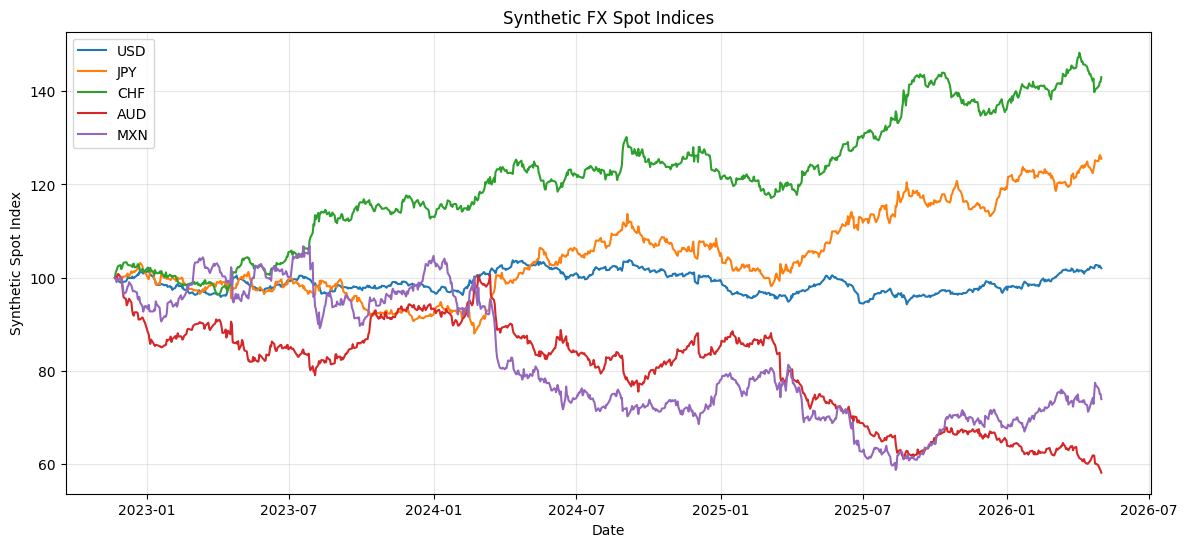

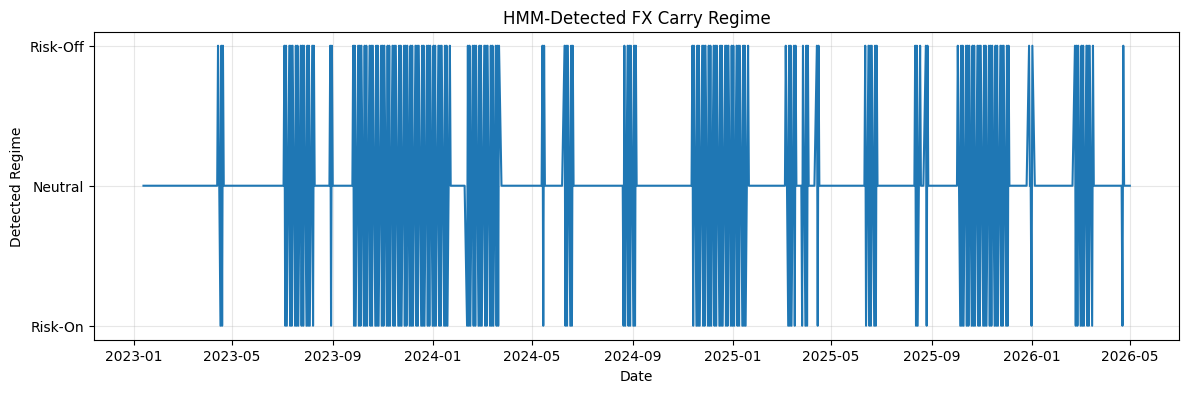

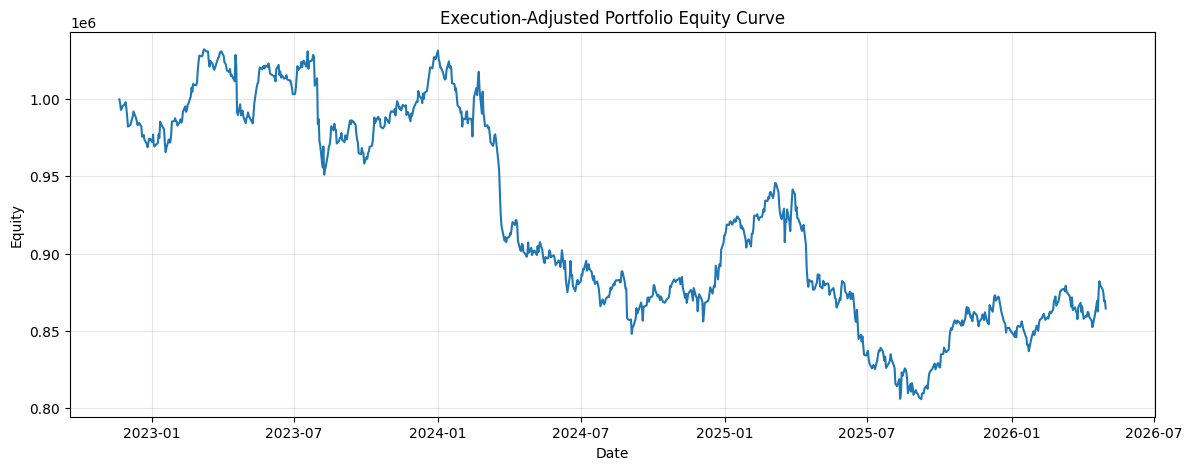

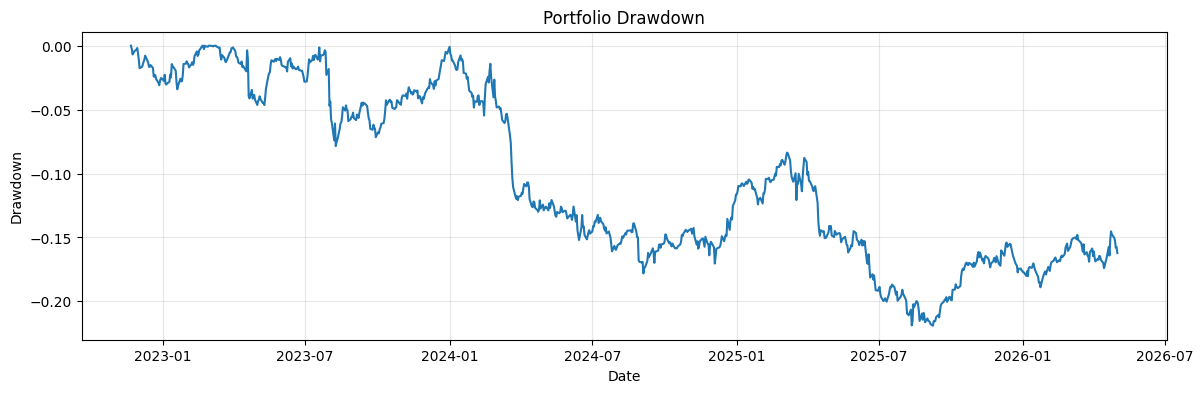

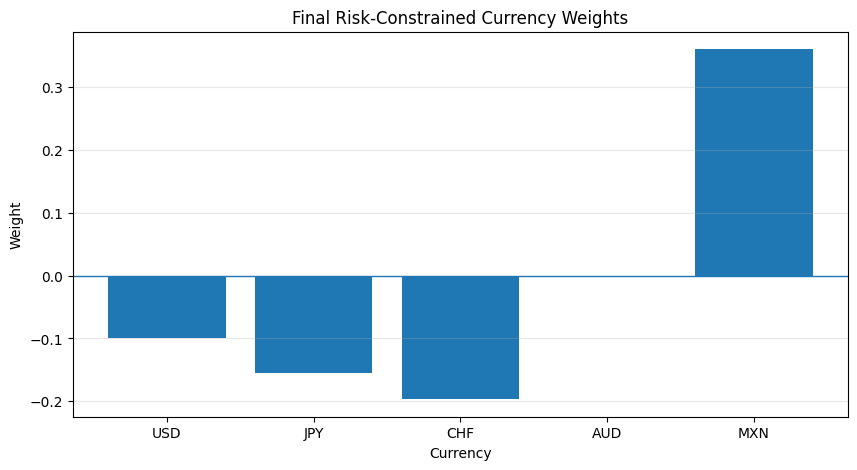


# Committee Report — Governance-First Agentic FX Carry Trading System

## Executive Summary

None

## Process Review

None

## Currency Views

null

## Allocation Review

null

## Stress Review

null

## Execution and Evaluation Review

null

## Audit Review

null

## Limitations

null

## Committee Decision Support

None

## Verification Status

Not verified — synthetic educational system; human review required.



================ FINAL SUMMARY ================
{
  "run_id": "fx_carry_agentic_20260502_165315",
  "latest_detected_regime": "Neutral / Compression",
  "latest_regime_confidence": 0.9999985202732239,
  "data_quality_status": "PASS",
  "selected_pairs": [
    "MXN/CHF",
    "MXN/JPY",
    "MXN/USD"
  ],
  "final_currency_weights": {
    "USD": -0.09872062661343076,
    "JPY": -0.15461645412292782,
    "CHF": -0.19666291926364143,
    "AUD": 0.0,
    "MXN": 0.36
  },
  "stress_risk_flag": "AMBER",
  "worst_stress_scenario": "high_yield_crash",
  "final_equity": 864557.3709481864,
  "max_drawdown": -0.21906496459132418,
  "annualized_return": -0.03733266344912471,
  "annualized_volatility": 0.08257434066007485,
  "sharpe_ratio": -0.45210973712533997,
  "audit_zip": "/content/fx_carry_agentic_20260502_165315_audit_bundle.zip",
  "verification_status": "Not verified \u2014 synthetic educational system; human review required."
}

================ IMPORTANT NOTICE ================
Not verif

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# ============================================================
# CELL 10 — FINAL CHARTS, REPORT DISPLAY, DOWNLOADABLE AUDIT ZIP
# ============================================================

from google.colab import files

# ------------------------------------------------------------
# Charts
# ------------------------------------------------------------

data = final_state["synthetic_data"]
ex = final_state["execution_df"]
hmm_df = final_state["hmm_detected_regimes"]

# 1. Spot indices
plt.figure(figsize=(14, 6))
for c in CONFIG["currencies"]:
    plt.plot(data.index, data[f"spot_{c}"], label=c)
plt.title("Synthetic FX Spot Indices")
plt.xlabel("Date")
plt.ylabel("Synthetic Spot Index")
plt.legend()
plt.grid(True, alpha=0.3)
spot_fig = FIGURE_DIR / "synthetic_fx_spot_indices.png"
plt.savefig(spot_fig, dpi=200, bbox_inches="tight")
plt.show()

# 2. HMM detected regimes
regime_map_plot = {
    "Risk-On Carry": 0,
    "Neutral / Compression": 1,
    "Risk-Off Carry-Unwind": 2
}
plt.figure(figsize=(14, 4))
plot_series = hmm_df["detected_regime_name"].map(regime_map_plot)
plt.plot(hmm_df.index, plot_series)
plt.yticks([0, 1, 2], ["Risk-On", "Neutral", "Risk-Off"])
plt.title("HMM-Detected FX Carry Regime")
plt.xlabel("Date")
plt.ylabel("Detected Regime")
plt.grid(True, alpha=0.3)
regime_fig = FIGURE_DIR / "hmm_detected_regime.png"
plt.savefig(regime_fig, dpi=200, bbox_inches="tight")
plt.show()

# 3. Equity curve
plt.figure(figsize=(14, 5))
plt.plot(ex.index, ex["equity"])
plt.title("Execution-Adjusted Portfolio Equity Curve")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.grid(True, alpha=0.3)
equity_fig = FIGURE_DIR / "execution_adjusted_equity_curve.png"
plt.savefig(equity_fig, dpi=200, bbox_inches="tight")
plt.show()

# 4. Drawdown
plt.figure(figsize=(14, 4))
plt.plot(ex.index, ex["drawdown"])
plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True, alpha=0.3)
drawdown_fig = FIGURE_DIR / "portfolio_drawdown.png"
plt.savefig(drawdown_fig, dpi=200, bbox_inches="tight")
plt.show()

# 5. Final allocation
alloc_df = pd.DataFrame([
    {"currency": c, "final_weight": w}
    for c, w in final_state["risk_allocation_report"]["final_currency_weights"].items()
])
plt.figure(figsize=(10, 5))
plt.bar(alloc_df["currency"], alloc_df["final_weight"])
plt.title("Final Risk-Constrained Currency Weights")
plt.xlabel("Currency")
plt.ylabel("Weight")
plt.axhline(0, linewidth=1)
plt.grid(True, axis="y", alpha=0.3)
alloc_fig = FIGURE_DIR / "final_currency_weights.png"
plt.savefig(alloc_fig, dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Refresh audit bundle after adding figures
# ------------------------------------------------------------

write_state_logs(final_state)

# Re-run audit packaging to include figures and Mermaid artifacts
final_state = audit_bundle_agent(final_state)

# ------------------------------------------------------------
# Final summary JSON
# ------------------------------------------------------------

final_summary = {
    "run_id": RUN_ID,
    "latest_detected_regime": final_state["hmm_report"]["latest_detected_regime"],
    "latest_regime_confidence": final_state["hmm_report"]["latest_regime_confidence"],
    "data_quality_status": final_state["data_quality_report"]["data_quality_status"],
    "selected_pairs": final_state["pair_report"]["selected_pairs"],
    "final_currency_weights": final_state["risk_allocation_report"]["final_currency_weights"],
    "stress_risk_flag": final_state["stress_report"]["stress_risk_flag"],
    "worst_stress_scenario": final_state["stress_report"]["worst_scenario"],
    "final_equity": final_state["execution_report"]["final_equity"],
    "max_drawdown": final_state["evaluation_report"]["maximum_drawdown"],
    "annualized_return": final_state["evaluation_report"]["annualized_net_return"],
    "annualized_volatility": final_state["evaluation_report"]["annualized_net_volatility"],
    "sharpe_ratio": final_state["evaluation_report"]["sharpe_ratio"],
    "audit_zip": final_state["audit_report"]["zip_path"],
    "verification_status": CONFIG["verification_status"]
}

summary_path = REPORT_DIR / "final_summary.json"
save_json(summary_path, final_summary)

# ------------------------------------------------------------
# Display committee report
# ------------------------------------------------------------

committee_md_path = REPORT_DIR / "committee_report.md"

if committee_md_path.exists():
    display(Markdown(committee_md_path.read_text(encoding="utf-8")))
else:
    display(Markdown("Committee report markdown file not found. Check artifacts folder."))

# ------------------------------------------------------------
# Display final summary
# ------------------------------------------------------------

print("\n================ FINAL SUMMARY ================")
print(json.dumps(final_summary, indent=2, default=str))

print("\n================ IMPORTANT NOTICE ================")
print(CONFIG["verification_status"])
print("This notebook uses synthetic data and is for educational/governance demonstration only.")
print("It is not investment advice and not approved for live trading.")

# ------------------------------------------------------------
# Download audit ZIP
# ------------------------------------------------------------

zip_path = final_state["audit_report"]["zip_path"]
print("\nAudit bundle ready:")
print(zip_path)

try:
    files.download(zip_path)
except Exception as e:
    print("Automatic download did not start. You can download manually from:")
    print(zip_path)
    print("Error:", e)

##3.CONCLUSION

**Conclusions**

This notebook has built a complete governance-first agentic workflow for FX carry trading. Its main contribution is not that it generates a final portfolio. A simple model could do that with a few lines of code. The real contribution is that it shows how a carry trading idea can be transformed into a structured, auditable, explainable, and risk-aware decision process. The notebook demonstrates that a trading system should not be judged only by whether it produces a signal or a performance chart. It should be judged by whether the full path from evidence to recommendation can be reviewed.

The FX carry trade is a useful case study because it appears simple but is actually dangerous when treated mechanically. The basic idea is to borrow or short a low-yield currency and invest in a higher-yield currency. If nothing goes wrong, the strategy may earn the interest-rate differential. But markets are not kind enough to keep the world still while the strategy collects carry. Exchange rates move. Volatility changes. Liquidity can deteriorate. Funding currencies can rally. High-yield currencies can crash. Transaction costs can rise. Investors can unwind similar positions at the same time. A carry strategy that looks stable in calm markets can become fragile in stress.

For this reason, the notebook treats carry as a risk premium rather than a guaranteed return. The system does not ask only which currencies have high yields. It asks whether the carry is supported by the regime, whether the currency has favorable momentum, whether volatility is tolerable, whether liquidity is adequate, whether the funding leg is safe to short, whether the portfolio is concentrated, whether the strategy survives stress, and whether the final result remains attractive after costs. That broader set of questions is what makes the workflow governance-first.

The use of synthetic data is central to the educational design. Synthetic data allow the notebook to create a controlled environment with five currencies and three regimes. The hidden regime is known to the data generator, but it is not directly given to the trading agents. This distinction is one of the most important lessons of the notebook. In real markets, the true regime is never handed to the trader. It must be inferred from observable evidence. The notebook preserves that discipline by allowing the HMM agent to infer regimes from observable features rather than from hidden truth.

The three-regime structure gives the system its macro logic. In a Risk-On Carry regime, high-yield currencies may be more attractive, volatility may be manageable, and funding currencies may remain weak or stable. In a Neutral or Compression regime, signals become less reliable and exposure should be reduced. In a Risk-Off Carry-Unwind regime, classic carry exposure can become dangerous because high-yield currencies may fall and funding currencies may rally. The model therefore does not apply one permanent rule to all environments. It changes its interpretation and sizing according to regime conditions.

The LangGraph structure is also important. The workflow is not just a sequence of calculations. It is a graph of agents that read from and write to shared state. This shared state records the synthetic data, quality checks, HMM regime output, currency memos, pair construction table, basket allocation, risk allocation, stress results, execution results, evaluation metrics, audit artifacts, and committee report. This is how the notebook creates traceability. Every important output has a producer, a purpose, and a place in the evidence chain.

The individual currency agents illustrate the appropriate role of generative AI in financial modeling. Claude is used as an interpretive agent, not as an autonomous trader. Each currency agent receives structured evidence and produces a bounded memo. The LLM can explain why MXN may be attractive but risky, why JPY may be useful as a funding currency but dangerous in stress, why CHF safe-haven behavior matters, why AUD is risk-sensitive, and why USD may have a mixed role. But the LLM does not generate the synthetic data, does not infer the regime, does not allocate capital, and does not approve the portfolio. Its job is to interpret structured evidence in a readable way.

The notebook also demonstrates a practical AI governance requirement: the system must know whether the LLM was actually used. A workflow that claims to have LLM-backed agents but silently falls back to deterministic rules is not transparent. This notebook records LLM call status, parse status, fallback status, model name, recommendation, confidence, and risk flags. If the LLM fails, the system can still run, but the failure is preserved. That is the correct institutional behavior. A failure should not be hidden merely because the code can continue.

The portfolio construction process shows why signal generation is not the same as trading. The currency agents produce views, but those views are not the final portfolio. The pair construction agent turns currency views into long-short structures. The basket coordinator combines selected pairs into a preliminary portfolio. The capital and risk allocation agent applies constraints. This layered process prevents a high carry score from automatically becoming a large allocation. It also allows the system to identify hidden concentration. Several selected pairs may appear different, but they may all be long global risk and short safe-haven funding currencies. The notebook makes that risk visible.

The corrected version of the pair construction and risk allocation logic also teaches an important practical lesson. Governance-first does not mean refusing to trade under every imperfect condition. The first version became too conservative and produced a zero portfolio in a Neutral or Compression regime. That result was technically safe but analytically trivial. A governed research system should be cautious, not inert. The corrected logic selects plausible research pairs when evidence exists, but then reduces size through risk controls. This is the right balance. The system should be able to express a research view while still documenting uncertainty and applying constraints.

The stress testing layer is one of the most important parts of the notebook. Carry strategies often fail during abrupt unwinds, not during ordinary market noise. The stress risk agent therefore tests scenarios such as global risk-off, JPY short squeeze, CHF safe-haven rally, high-yield currency crash, dollar funding squeeze, and liquidity evaporation. These scenarios are not designed to comfort the model. They are designed to expose the model's vulnerabilities. If the strategy fails under these scenarios, that failure is not an embarrassment. It is useful information.

The execution and financing layer adds another essential discipline. A carry trade is not implemented in a frictionless world. Spreads, slippage, financing costs, rollover assumptions, turnover, and liquidity penalties affect performance. The notebook therefore evaluates net returns, not only gross returns. This is vital because a strategy may appear profitable before costs but unattractive after costs. The execution agent forces the system to confront implementation reality before the model evaluation stage.

The model evaluation agent then assesses the final constrained, execution-adjusted portfolio. This ordering matters. The notebook does not evaluate raw signals as if they were deployable strategies. It evaluates the portfolio after risk controls and costs. The evaluation includes return, volatility, Sharpe ratio, drawdown, hit rate, cost drag, return attribution, regime-specific behavior, and governance checks. This gives a more complete picture of performance and avoids the common mistake of reducing model quality to a single attractive statistic.

The audit bundle agent turns the notebook run into a durable evidence package. This is one of the clearest expressions of the governance-first philosophy. A model result that cannot be reconstructed cannot be governed. The audit bundle preserves data, reports, logs, charts, configuration, currency memos, stress outputs, execution outputs, evaluation metrics, and the final report. It also records missing artifacts if any are absent. This makes the notebook more than a temporary computational exercise. It becomes a reviewable research record.

The committee report agent completes the workflow by translating technical evidence into institutional language. The report is not an approval. It is decision support. It explains the run, summarizes the evidence, discloses warnings, identifies limitations, and states that human review is required. This is important because language can easily overstate model quality. The committee report is designed to communicate clearly without turning synthetic results into validation.

The broader lesson of the notebook is that agentic AI in finance should not mean uncontrolled automation. It should mean disciplined decomposition. The model proposes, but the agents interpret, constrain, challenge, penalize, evaluate, document, and explain. The human committee remains responsible. This is the right relationship between AI and financial governance. AI can help structure the evidence, identify risks, write memos, and produce review packages. It should not replace accountability.

The notebook is limited. It uses synthetic data. It simplifies exchange-rate dynamics, interest-rate processes, liquidity behavior, financing costs, execution costs, and market microstructure. It does not include live FX quotes, broker-specific rollover terms, macroeconomic releases, central-bank communications, settlement conventions, cross-currency basis, margin rules, or legal documentation. These limitations matter. The notebook is not a live trading system. It is a teaching and research architecture.

Still, the architecture is valuable because it shows what a serious trading research workflow should look like. It demonstrates how to combine synthetic data, regime inference, LLM-backed interpretation, pair construction, risk controls, stress testing, execution realism, evaluation, audit, and committee reporting. It provides a template that can be adapted to oil futures, equity factors, rates strategies, credit spreads, volatility carry, or other systematic trading problems.

The final conclusion is simple. A trading system should not be trusted because it produces a signal. It should not be trusted because it uses agents. It should not be trusted because it uses an LLM. It should not be trusted because it produces a beautiful chart. It should be trusted only to the extent that its evidence, assumptions, controls, risks, failures, costs, and limitations can be reviewed. This notebook is designed around that standard. It is not an autonomous trader. It is a governed research organization expressed in code.